<a href="https://colab.research.google.com/github/okothjosh/okothjosh/blob/main/Copy_of_matatu_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install gtfs-kit geopandas prophet xgboost lightgbm tensorflow streamlit folium pydeck

In [4]:
import os
import zipfile

# Ensure project_base_dir is defined from previous steps
project_base_dir = '/content/drive/MyDrive/matatu_ml/'

# Define raw and processed data directories
raw_data_dir = os.path.join(project_base_dir, 'data', 'raw')
processed_data_dir = os.path.join(project_base_dir, 'data', 'processed')

# Create directories if they don't exist
os.makedirs(raw_data_dir, exist_ok=True)
os.makedirs(processed_data_dir, exist_ok=True)

# Use the GTFS zip file provided by the user
gtfs_zip_path = '/content/gtfs (1).zip' # Corrected path

# Unzip the GTFS data
# Check if any GTFS feed (identified by routes.txt) exists in raw_data_dir already
found_feed_dir_after_check = None
for root, dirs, files in os.walk(raw_data_dir):
    if 'routes.txt' in files:
        found_feed_dir_after_check = root
        break

if found_feed_dir_after_check is None: # Only unzip if not already extracted
    print(f"Extracting GTFS data from {gtfs_zip_path} to {raw_data_dir}...")
    try:
        with zipfile.ZipFile(gtfs_zip_path, 'r') as zip_ref:
            zip_ref.extractall(raw_data_dir) # Extract all contents into raw_data_dir
        print("Extraction complete.")
    except zipfile.BadZipFile:
        print(f"Error: {gtfs_zip_path} is not a valid zip file. Please check the file.")
        raise # Critical error, cannot proceed
    except FileNotFoundError:
        print(f"Error: Zip file not found at {gtfs_zip_path}. Please ensure it is in /content/.")
        raise # Critical error, cannot proceed
else:
    print(f"GTFS data appears to be already extracted in {found_feed_dir_after_check}.")

# Identify the actual GTFS feed directory (it might be nested one level deeper or named differently)
actual_gtfs_feed_dir = None
# Look for a directory containing 'routes.txt' within raw_data_dir after extraction
for root, dirs, files in os.walk(raw_data_dir):
    if 'routes.txt' in files:
        actual_gtfs_feed_dir = root
        break

if actual_gtfs_feed_dir is None:
    print("Error: Could not find 'routes.txt' in any subdirectory of raw_data_dir after extraction.")
    print("Please verify the contents of the extracted GTFS data.")
    # Fallback or raise error
    raise FileNotFoundError("GTFS feed directory not found.")

print(f"Actual GTFS feed directory identified: {actual_gtfs_feed_dir}")

Extracting GTFS data from /content/gtfs (1).zip to /content/drive/MyDrive/matatu_ml/data/raw...
Extraction complete.
Actual GTFS feed directory identified: /content/drive/MyDrive/matatu_ml/data/raw


### 2. Parse GTFS Data with `gtfs-kit` and Export to CSV

Now, I will use `gtfs-kit` to read the GTFS feed and then export the `routes`, `stops`, `stop_times`, and `shapes` tables into individual CSV files. These CSVs will be saved in the `data/processed` folder.

In [5]:
import gtfs_kit as gk
import pandas as pd

# Load the GTFS feed
print(f"Loading GTFS feed from {actual_gtfs_feed_dir}...")
feed = gk.read_feed(actual_gtfs_feed_dir, dist_units='mi')
print("GTFS feed loaded successfully.")

# Define the tables to export
tables_to_export = {
    'routes': feed.routes,
    'stops': feed.stops,
    'stop_times': feed.stop_times,
    'shapes': feed.shapes
}

# Export each table to a CSV file
for table_name, df in tables_to_export.items():
    output_path = os.path.join(processed_data_dir, f'{table_name}.csv')
    print(f"Exporting {table_name} to {output_path}...")
    df.to_csv(output_path, index=False)
    print(f"Exported {len(df)} rows to {output_path}")

print("All specified GTFS tables exported to CSV successfully.")

Loading GTFS feed from /content/drive/MyDrive/matatu_ml/data/raw...
GTFS feed loaded successfully.
Exporting routes to /content/drive/MyDrive/matatu_ml/data/processed/routes.csv...
Exported 136 rows to /content/drive/MyDrive/matatu_ml/data/processed/routes.csv
Exporting stops to /content/drive/MyDrive/matatu_ml/data/processed/stops.csv...
Exported 4273 rows to /content/drive/MyDrive/matatu_ml/data/processed/stops.csv
Exporting stop_times to /content/drive/MyDrive/matatu_ml/data/processed/stop_times.csv...
Exported 7533 rows to /content/drive/MyDrive/matatu_ml/data/processed/stop_times.csv
Exporting shapes to /content/drive/MyDrive/matatu_ml/data/processed/shapes.csv...
Exported 36483 rows to /content/drive/MyDrive/matatu_ml/data/processed/shapes.csv
All specified GTFS tables exported to CSV successfully.


In [7]:
import json
import pandas as pd

# Path to the provided JSON file
json_file_path = '/content/nairobi_weather_2024.json' # Corrected path

print(f"Loading weather data from {json_file_path}...")

# Load the JSON data from the file
with open(json_file_path, 'r') as f:
    weather_data = json.load(f)

# Extract hourly data
hourly_df = pd.DataFrame(weather_data['hourly'])

# Convert time to datetime objects
hourly_df['time'] = pd.to_datetime(hourly_df['time'])

# Rename columns for clarity (assuming similar structure to Open-Meteo API)
hourly_df.rename(columns={
    'precipitation': 'rainfall_mm',
    'temperature_2m': 'temperature_c',
    'wind_speed_10m': 'wind_speed'
}, inplace=True)

print("Weather data loaded and processed successfully from JSON file.")

# Display the first 5 rows of the DataFrame
display(hourly_df.head())

Loading weather data from /content/nairobi_weather_2024.json...
Weather data loaded and processed successfully from JSON file.


,time,temperature_c,rain,wind_speed
0,2024-01-01 00:00:00,15.4,0.0,4.6
1,2024-01-01 01:00:00,16.6,0.0,3.6
2,2024-01-01 02:00:00,15.8,0.0,6.2
3,2024-01-01 03:00:00,15.4,0.0,6.4
4,2024-01-01 04:00:00,16.4,0.0,4.4


In [8]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.2 MB/s eta 0:00:00


In [9]:
!pip install osmnx
import geopandas
from shapely.geometry import LineString, Point
import osmnx as ox

# Load the shapes data which defines the route geometries
shapes_df = pd.read_csv(os.path.join(processed_data_dir, 'shapes.csv'))

print("Shapes data loaded successfully.")

# Group by shape_id and create LineString geometries for each shape
def create_linestring(group):
    return LineString(group[['shape_pt_lon', 'shape_pt_lat']].values)

# Sort by sequence to ensure correct line order
shapes_df = shapes_df.sort_values(by=['shape_id', 'shape_pt_sequence'])

# Create a GeoDataFrame from the LineStrings
# Use 'EPSG:4326' (WGS 84) as the CRS, which is standard for lat/lon
# We'll create a pandas DataFrame first and then convert to GeoDataFrame explicitly setting the geometry
geometries = shapes_df.groupby('shape_id').apply(create_linestring, include_groups=False)
routes_gdf = pd.DataFrame({'geometry': geometries}).reset_index()
routes_gdf = geopandas.GeoDataFrame(routes_gdf, geometry='geometry', crs="EPSG:4326")

print("Route geometries created and stored in GeoDataFrame.")
display(routes_gdf.head())

Shapes data loaded successfully.
Route geometries created and stored in GeoDataFrame.


,shape_id,geometry
0,10106110,"LINESTRING (36.75878 -1.17384, 36.75902 -1.174..."
1,10106111,"LINESTRING (36.8225 -1.28142, 36.82238 -1.2813..."
2,10107110,"LINESTRING (36.73198 -1.19437, 36.73557 -1.194..."
3,10107111,"LINESTRING (36.82478 -1.28304, 36.82583 -1.281..."
4,10108110,"LINESTRING (36.76672 -1.21956, 36.76841 -1.220..."


In [ ]:
display(hourly_df.head())

In [10]:
import osmnx as ox
import geopandas as gpd
from shapely.geometry import LineString, Point, Polygon, MultiPolygon
import pandas as pd
import uuid
import os

# Define cache directory
cache_dir = os.path.join(processed_data_dir, 'cache')
os.makedirs(cache_dir, exist_ok=True)

# Path for the combined cached POIs GeoDataFrame
combined_pois_cache_path = os.path.join(cache_dir, 'all_pois_gdf.parquet')

# List of columns expected in the final all_pois_gdf
# This helps in creating an empty GeoDataFrame if no POIs are found
poi_cols_to_keep = ['osm_id', 'geometry', 'element_type', 'name', 'amenity', 'shop', 'office', 'building', 'healthcare', 'shape_id']

# Try to load from combined cache first
if os.path.exists(combined_pois_cache_path):
    print(f"Loading all POIs from cache: {combined_pois_cache_path}")
    all_pois_gdf = gpd.read_parquet(combined_pois_cache_path)
    print(f"Loaded {len(all_pois_gdf)} POIs from cache.")
else:
    print("Combined POIs cache not found. Proceeding with individual POI extraction and caching...")

    # Project the GeoDataFrame to a local CRS to perform accurate buffering in meters
    print("Projecting routes_gdf to a local UTM CRS (EPSG:32737) for accurate buffering...")
    routes_gdf_proj = routes_gdf.to_crs(epsg=32737)

    # Create a 500-meter buffer around each route
    buffer_distance_m = 500
    print(f"Creating {buffer_distance_m} meter buffer around each route...")
    routes_buffer = routes_gdf_proj.buffer(buffer_distance_m)

    # Convert the buffered geometries back to EPSG:4326 for Overpass API query
    routes_buffer_gdf = gpd.GeoDataFrame(geometry=routes_buffer, crs=32737).to_crs(epsg=4326)

    print("Buffers created and reprojected. Querying OSM for POIs...")

    # Define the POI tags to query
    poi_tags = {
        'shop': True,
        'amenity': ['school', 'hospital', 'pharmacy', 'university', 'college'],
        'office': True,
        'building': ['hospital', 'school', 'university', 'college', 'office', 'government', 'commercial'],
        'healthcare': ['hospital', 'clinic', 'pharmacy']
    }

    # Initialize a list to store GeoDataFrames of POIs for concatenation
    all_pois_list = []

    # Iterate through each route's buffer and query POIs
    for index, row in routes_buffer_gdf.iterrows():
        route_shape_id = routes_gdf.loc[index, 'shape_id']
        buffer_polygon = row.geometry

        # Define cache path for this specific route's POIs
        single_route_cache_path = os.path.join(cache_dir, f'pois_shape_{route_shape_id}.parquet')

        if os.path.exists(single_route_cache_path):
            print(f"Loading POIs for shape_id {route_shape_id} from cache: {single_route_cache_path}")
            current_pois = gpd.read_parquet(single_route_cache_path)
            all_pois_list.append(current_pois)
            continue # Move to next route if loaded from cache

        # If not in cache, proceed with OSMnx query
        if buffer_polygon.is_empty:
            continue

        try:
            # Ensure the polygon is valid for osmnx
            if not buffer_polygon.is_valid:
                buffer_polygon = buffer_polygon.buffer(0) # Attempt to fix invalid polygons

            pois = ox.features_from_polygon(buffer_polygon, tags=poi_tags)

            if not pois.empty:
                # OSMnx often returns osm_id as index. Reset index to make it a column.
                if pois.index.name == 'osm_id':
                    pois = pois.reset_index()

                # Ensure 'osm_id' column exists. If not, create it and fill with pd.NA
                if 'osm_id' not in pois.columns:
                    pois['osm_id'] = pd.NA

                pois['shape_id'] = route_shape_id

                # Fill any remaining NaN osm_ids with a unique placeholder string.
                # This prevents dropping these rows due to missing OSM IDs in cleaning.
                null_osm_mask = pois['osm_id'].isnull()
                if null_osm_mask.any():
                    # Generate unique IDs for nulls using UUID for global uniqueness
                    pois.loc[null_osm_mask, 'osm_id'] = [f"MISSING_OSMID_{route_shape_id}_{i}_{uuid.uuid4().hex[:8]}"
                                                         for i in range(null_osm_mask.sum())]

                # Ensure all required columns are present, add if missing and fill with pd.NA
                for col in poi_cols_to_keep:
                    if col not in pois.columns:
                        pois[col] = pd.NA

                current_pois = pois[poi_cols_to_keep] # Select only the desired and ensured columns

                # Cache this individual route's POIs
                current_pois.to_parquet(single_route_cache_path, index=False)
                print(f"Cached POIs for shape_id {route_shape_id} to {single_route_cache_path}")

                all_pois_list.append(current_pois)

        except Exception as e:
            print(f"Error querying POIs for shape_id {route_shape_id}: {e}")

    # Concatenate all GeoDataFrames from the list
    if all_pois_list:
        all_pois_gdf = pd.concat(all_pois_list, ignore_index=True)
        # Save the combined POIs GeoDataFrame to a master cache file
        all_pois_gdf.to_parquet(combined_pois_cache_path, index=False)
        print(f"Saved combined POIs to master cache: {combined_pois_cache_path}")
    else:
        # Create an empty GeoDataFrame with correct columns and CRS if no POIs were found
        all_pois_gdf = gpd.GeoDataFrame(columns=poi_cols_to_keep, geometry='geometry', crs="EPSG:4326")
        print("No POIs found for any routes after processing.")

print(f"Found {len(all_pois_gdf)} POIs across all routes.")
display(all_pois_gdf.head())

# Save the POIs to a CSV file (as originally requested)
output_pois_path = os.path.join(processed_data_dir, 'routes_pois.csv')
all_pois_gdf.to_csv(output_pois_path, index=False)
print(f"All POIs saved to {output_pois_path}")

Combined POIs cache not found. Proceeding with individual POI extraction and caching...
Projecting routes_gdf to a local UTM CRS (EPSG:32737) for accurate buffering...
Creating 500 meter buffer around each route...
Buffers created and reprojected. Querying OSM for POIs...
Cached POIs for shape_id 10106110 to /content/drive/MyDrive/matatu_ml/data/processed/cache/pois_shape_10106110.parquet
Cached POIs for shape_id 10106111 to /content/drive/MyDrive/matatu_ml/data/processed/cache/pois_shape_10106111.parquet
Cached POIs for shape_id 10107110 to /content/drive/MyDrive/matatu_ml/data/processed/cache/pois_shape_10107110.parquet
Cached POIs for shape_id 10107111 to /content/drive/MyDrive/matatu_ml/data/processed/cache/pois_shape_10107111.parquet
Cached POIs for shape_id 10108110 to /content/drive/MyDrive/matatu_ml/data/processed/cache/pois_shape_10108110.parquet
Cached POIs for shape_id 10108111 to /content/drive/MyDrive/matatu_ml/data/processed/cache/pois_shape_10108111.parquet
Cached POIs f

,osm_id,geometry,element_type,name,amenity,shop,office,building,healthcare,shape_id
0,MISSING_OSMID_10106110_0_f89afbb6,POINT (36.81492 -1.27217),NaN,Aga Khan Nursery,school,NaN,NaN,NaN,NaN,10106110
1,MISSING_OSMID_10106110_1_74d85f2d,POINT (36.80451 -1.23001),NaN,City Walk - Village Market,NaN,shoes,NaN,NaN,NaN,10106110
2,MISSING_OSMID_10106110_2_1edabe76,POINT (36.80146 -1.22415),NaN,River Garden Centre,NaN,garden_centre,NaN,NaN,NaN,10106110
3,MISSING_OSMID_10106110_3_ef97c57d,POINT (36.82025 -1.24999),NaN,Onn The Way Supermarket Muthaiga,NaN,supermarket,NaN,NaN,NaN,10106110
4,MISSING_OSMID_10106110_4_d3033ddd,POINT (36.80496 -1.22869),NaN,Dorman,NaN,mall,NaN,NaN,NaN,10106110


All POIs saved to /content/drive/MyDrive/matatu_ml/data/processed/routes_pois.csv


### 4. Load EPRA Monthly Diesel/Petrol Prices

Now, I will load the monthly diesel and petrol prices from the provided CSV file into a pandas DataFrame.

In [13]:
epra_prices_path = '/content/Pump Prices  Energy and Petroleum Regulatory Authority.csv'
print(f"Loading EPRA prices from {epra_prices_path}...")
epra_df = pd.read_csv(epra_prices_path)
print("EPRA prices loaded successfully.")
display(epra_df.head())

Loading EPRA prices from /content/Pump Prices  Energy and Petroleum Regulatory Authority.csv...
EPRA prices loaded successfully.


,From,To,Town,Super (PMS),Diesel (AGO)
0,15-12-2025,14-01-2026,Nairobi,184.52,171.47
1,15-11-2025,14-12-2025,Nairobi,184.52,171.47
2,15-10-2025,14-11-2025,Nairobi,184.52,171.47
3,15-09-2025,14-10-2025,Nairobi,184.52,171.47
4,15-08-2025,14-09-2025,Nairobi,185.31,171.58


### 5. Schema Validation

#### Validate EPRA Monthly Diesel/Petrol Prices (`epra_df`)

In [14]:
print('--- Validating epra_df ---')

# 1. Assert row counts (example: expecting at least 12 months data for 2 years = 24 rows)
expected_min_rows_epra = 12
if len(epra_df) < expected_min_rows_epra:
    print(f"Warning: epra_df has {len(epra_df)} rows, expected at least {expected_min_rows_epra}.")
else:
    print(f"epra_df row count ({len(epra_df)}) is acceptable.")

# 2. Check for expected columns
expected_epra_columns = ['From', 'To', 'Town', 'Super (PMS)', 'Diesel (AGO)']
missing_epra_cols = [col for col in expected_epra_columns if col not in epra_df.columns]
if missing_epra_cols:
    raise ValueError(f"Missing expected columns in epra_df: {missing_epra_cols}")
else:
    print("All expected columns are present in epra_df.")

# 3. Convert 'From' and 'To' columns to datetime and validate date range
epra_df['From_Date'] = pd.to_datetime(epra_df['From'], format='%d-%m-%Y')
epra_df['To_Date'] = pd.to_datetime(epra_df['To'], format='%d-%m-%Y')

# Assuming prices are for Nairobi, 'Town' should ideally be consistent
if not (epra_df['Town'] == 'Nairobi').all():
    print("Warning: 'Town' column in epra_df contains values other than 'Nairobi'.")

print(f"EPRA price data date range: {epra_df['From_Date'].min().strftime('%Y-%m-%d')} to {epra_df['To_Date'].max().strftime('%Y-%m-%d')}")

# 4. Check for nulls in primary key candidates (e.g., 'From_Date' and 'Town')
if epra_df[['From_Date', 'Town']].isnull().any().any():
    raise ValueError("Null values found in primary key candidates ('From_Date', 'Town') in epra_df.")
else:
    print("No nulls found in 'From_Date' or 'Town' in epra_df.")

print('epra_df validation complete.')

--- Validating epra_df ---
epra_df row count (19) is acceptable.
All expected columns are present in epra_df.
EPRA price data date range: 2024-11-15 to 2026-05-14
No nulls found in 'From_Date' or 'Town' in epra_df.
epra_df validation complete.


#### Validate Hourly Weather Data (`hourly_df`)

In [15]:
print('\n--- Validating hourly_df ---')

# 1. Assert row counts (expecting a full year of hourly data, 365*24 = 8760 rows, for 2 years = ~17520)
expected_min_rows_hourly = 8760 * 2 # Minimum for two years
if len(hourly_df) < expected_min_rows_hourly:
    print(f"Warning: hourly_df has {len(hourly_df)} rows, expected at least {expected_min_rows_hourly}. Data might be incomplete.")
else:
    print(f"hourly_df row count ({len(hourly_df)}) is acceptable.")

# 2. Check for expected columns
expected_hourly_columns = ['time', 'temperature_c', 'rain', 'wind_speed'] # 'precipitation' was renamed to 'rainfall_mm'
missing_hourly_cols = [col for col in expected_hourly_columns if col not in hourly_df.columns]
if missing_hourly_cols:
    raise ValueError(f"Missing expected columns in hourly_df: {missing_hourly_cols}")
else:
    print("All expected columns are present in hourly_df.")

# 3. Validate 'time' column as datetime and check its range
if not pd.api.types.is_datetime64_any_dtype(hourly_df['time']):
    raise TypeError("'time' column in hourly_df is not of datetime type.")

print(f"Weather data date range: {hourly_df['time'].min().strftime('%Y-%m-%d %H:%M')} to {hourly_df['time'].max().strftime('%Y-%m-%d %H:%M')}")

# 4. Check for nulls in 'time' (primary key)
if hourly_df['time'].isnull().any():
    raise ValueError("Null values found in 'time' column (primary key) in hourly_df.")
else:
    print("No nulls found in 'time' in hourly_df.")

print('hourly_df validation complete.')


--- Validating hourly_df ---
hourly_df row count (18984) is acceptable.
All expected columns are present in hourly_df.
Weather data date range: 2024-01-01 00:00 to 2026-03-01 23:00
No nulls found in 'time' in hourly_df.
hourly_df validation complete.


#### Validate GTFS `routes` data (`feed.routes`)

In [16]:
print('\n--- Validating feed.routes ---')
routes_df = feed.routes

# 1. Assert row counts (e.g., expecting more than 0 routes)
if len(routes_df) == 0:
    raise ValueError("routes_df has 0 rows. GTFS routes data is empty.")
else:
    print(f"routes_df row count ({len(routes_df)}) is acceptable.")

# 2. Check for expected columns
expected_route_columns = ['route_id', 'agency_id', 'route_short_name', 'route_type']
missing_route_cols = [col for col in expected_route_columns if col not in routes_df.columns]
if missing_route_cols:
    raise ValueError(f"Missing expected columns in routes_df: {missing_route_cols}")
else:
    print("All expected columns are present in routes_df.")

# 3. Check for nulls in primary key ('route_id')
if routes_df['route_id'].isnull().any():
    raise ValueError("Null values found in 'route_id' in routes_df.")
else:
    print("No nulls found in 'route_id' in routes_df.")

print('feed.routes validation complete.')


--- Validating feed.routes ---
routes_df row count (136) is acceptable.
All expected columns are present in routes_df.
No nulls found in 'route_id' in routes_df.
feed.routes validation complete.


#### Validate GTFS `stops` data (`feed.stops`)

In [17]:
print('\n--- Validating feed.stops ---')
stops_df = feed.stops

# 1. Assert row counts (e.g., expecting more than 0 stops)
if len(stops_df) == 0:
    raise ValueError("stops_df has 0 rows. GTFS stops data is empty.")
else:
    print(f"stops_df row count ({len(stops_df)}) is acceptable.")

# 2. Check for expected columns
expected_stop_columns = ['stop_id', 'stop_name', 'stop_lat', 'stop_lon']
missing_stop_cols = [col for col in expected_stop_columns if col not in stops_df.columns]
if missing_stop_cols:
    raise ValueError(f"Missing expected columns in stops_df: {missing_stop_cols}")
else:
    print("All expected columns are present in stops_df.")

# 3. Check for nulls in primary key ('stop_id') and coordinates
if stops_df['stop_id'].isnull().any():
    raise ValueError("Null values found in 'stop_id' in stops_df.")
if stops_df[['stop_lat', 'stop_lon']].isnull().any().any():
    raise ValueError("Null values found in 'stop_lat' or 'stop_lon' in stops_df.")
else:
    print("No nulls found in 'stop_id', 'stop_lat', or 'stop_lon' in stops_df.")

print('feed.stops validation complete.')


--- Validating feed.stops ---
stops_df row count (4273) is acceptable.
All expected columns are present in stops_df.
No nulls found in 'stop_id', 'stop_lat', or 'stop_lon' in stops_df.
feed.stops validation complete.


#### Validate GTFS `stop_times` data (`feed.stop_times`)

In [18]:
print('\n--- Validating feed.stop_times ---')
stop_times_df = feed.stop_times

# 1. Assert row counts (e.g., expecting more than 0 stop times)
if len(stop_times_df) == 0:
    raise ValueError("stop_times_df has 0 rows. GTFS stop_times data is empty.")
else:
    print(f"stop_times_df row count ({len(stop_times_df)}) is acceptable.")

# 2. Check for expected columns
expected_stop_time_columns = ['trip_id', 'arrival_time', 'departure_time', 'stop_id', 'stop_sequence']
missing_stop_time_cols = [col for col in expected_stop_time_columns if col not in stop_times_df.columns]
if missing_stop_time_cols:
    raise ValueError(f"Missing expected columns in stop_times_df: {missing_stop_time_cols}")
else:
    print("All expected columns are present in stop_times_df.")

# 3. Check for nulls in essential columns
if stop_times_df[['trip_id', 'stop_id', 'stop_sequence']].isnull().any().any():
    raise ValueError("Null values found in 'trip_id', 'stop_id', or 'stop_sequence' in stop_times_df.")
else:
    print("No nulls found in 'trip_id', 'stop_id', or 'stop_sequence' in stop_times_df.")

# 4. Validate time format (can be tricky with GTFS, but basic check)
# Assuming times are strings like 'HH:MM:SS'
# A more robust check would convert to timedelta, but for schema, we just check non-null
if stop_times_df['arrival_time'].isnull().any() or stop_times_df['departure_time'].isnull().any():
    print("Warning: Null values found in 'arrival_time' or 'departure_time' in stop_times_df. This might be acceptable depending on GTFS spec.")

print('feed.stop_times validation complete.')


--- Validating feed.stop_times ---
stop_times_df row count (7533) is acceptable.
All expected columns are present in stop_times_df.
No nulls found in 'trip_id', 'stop_id', or 'stop_sequence' in stop_times_df.
feed.stop_times validation complete.


#### Validate GTFS `shapes` data (`feed.shapes`)

In [19]:
print('\n--- Validating feed.shapes ---')
shapes_from_feed_df = feed.shapes # Use a distinct name to avoid confusion with the loaded shapes_df

# 1. Assert row counts (e.g., expecting more than 0 shape points)
if len(shapes_from_feed_df) == 0:
    raise ValueError("shapes_df has 0 rows. GTFS shapes data is empty.")
else:
    print(f"shapes_df row count ({len(shapes_from_feed_df)}) is acceptable.")

# 2. Check for expected columns
expected_shape_columns = ['shape_id', 'shape_pt_lat', 'shape_pt_lon', 'shape_pt_sequence']
missing_shape_cols = [col for col in expected_shape_columns if col not in shapes_from_feed_df.columns]
if missing_shape_cols:
    raise ValueError(f"Missing expected columns in shapes_df: {missing_shape_cols}")
else:
    print("All expected columns are present in shapes_df.")

# 3. Check for nulls in primary key candidates and coordinates
if shapes_from_feed_df[['shape_id', 'shape_pt_lat', 'shape_pt_lon', 'shape_pt_sequence']].isnull().any().any():
    raise ValueError("Null values found in essential columns in shapes_df.")
else:
    print("No nulls found in 'shape_id', 'shape_pt_lat', 'shape_pt_lon', or 'shape_pt_sequence' in shapes_df.")

print('feed.shapes validation complete.')


--- Validating feed.shapes ---
shapes_df row count (36483) is acceptable.
All expected columns are present in shapes_df.
No nulls found in 'shape_id', 'shape_pt_lat', 'shape_pt_lon', or 'shape_pt_sequence' in shapes_df.
feed.shapes validation complete.


#### Validate `routes_gdf` (GeoDataFrame of Route Geometries)

In [20]:
print('\n--- Validating routes_gdf ---')

# 1. Assert row counts (should correspond to number of unique shapes)
num_unique_shapes = shapes_df['shape_id'].nunique()
if len(routes_gdf) != num_unique_shapes:
    print(f"Warning: routes_gdf has {len(routes_gdf)} rows, but there are {num_unique_shapes} unique shape_ids. This might indicate an issue during GeoDataFrame creation.")
else:
    print(f"routes_gdf row count ({len(routes_gdf)}) matches unique shape_ids.")

# 2. Check for expected columns and geometry type
if 'geometry' not in routes_gdf.columns:
    raise ValueError("'geometry' column not found in routes_gdf.")
if not all(isinstance(geom, LineString) for geom in routes_gdf.geometry if geom is not None):
    print("Warning: Not all geometries in routes_gdf are LineString objects.")

# 3. Validate CRS
if routes_gdf.crs != 'EPSG:4326':
    raise ValueError(f"CRS of routes_gdf is {routes_gdf.crs}, expected EPSG:4326.")
else:
    print("routes_gdf has correct CRS (EPSG:4326).")

# 4. Check for null geometries
if routes_gdf['geometry'].isnull().any():
    print("Warning: Null geometries found in routes_gdf.")
else:
    print("No null geometries found in routes_gdf.")

print('routes_gdf validation complete.')


--- Validating routes_gdf ---
routes_gdf row count (272) matches unique shape_ids.
routes_gdf has correct CRS (EPSG:4326).
No null geometries found in routes_gdf.
routes_gdf validation complete.


#### Validate `all_pois_gdf` (GeoDataFrame of POIs)

In [21]:
print('\n--- Validating all_pois_gdf ---')

# 1. Assert row counts (expecting more than 0 POIs if query was successful)
if len(all_pois_gdf) == 0:
    print("Warning: all_pois_gdf has 0 rows. No POIs were found or extracted.")
else:
    print(f"all_pois_gdf row count ({len(all_pois_gdf)}) is acceptable.")

# 2. Check for expected columns and geometry type
expected_poi_gdf_columns = ['osm_id', 'geometry', 'element_type', 'name', 'shape_id']
missing_poi_cols = [col for col in expected_poi_gdf_columns if col not in all_pois_gdf.columns]
if missing_poi_cols:
    print(f"Warning: Missing expected columns in all_pois_gdf: {missing_poi_cols}")

if 'geometry' not in all_pois_gdf.columns:
    raise ValueError("'geometry' column not found in all_pois_gdf.")
# Check if geometries are Points or Polygons (OSMnx returns both)
if not all(geom.geom_type in ['Point', 'Polygon', 'MultiPolygon'] for geom in all_pois_gdf.geometry if geom is not None):
    print("Warning: Not all geometries in all_pois_gdf are Point/Polygon/MultiPolygon objects.")

# 3. Validate CRS
if all_pois_gdf.crs != 'EPSG:4326':
    raise ValueError(f"CRS of all_pois_gdf is {all_pois_gdf.crs}, expected EPSG:4326.")
else:
    print("all_pois_gdf has correct CRS (EPSG:4326).")

# 4. Check for nulls in essential columns
if all_pois_gdf[['osm_id', 'shape_id']].isnull().any().any():
    print("Warning: Null values found in 'osm_id' or 'shape_id' in all_pois_gdf.")
else:
    print("No nulls found in 'osm_id' or 'shape_id' in all_pois_gdf.")

print('all_pois_gdf validation complete.')


--- Validating all_pois_gdf ---
all_pois_gdf row count (91143) is acceptable.
all_pois_gdf has correct CRS (EPSG:4326).
No nulls found in 'osm_id' or 'shape_id' in all_pois_gdf.
all_pois_gdf validation complete.


In [22]:
print('\n--- DEBUG: Inspecting all_pois_gdf before cleaning ---')
print(f"Shape of all_pois_gdf: {all_pois_gdf.shape}")
print(f"Null counts in 'osm_id': {all_pois_gdf['osm_id'].isnull().sum()}")
print(f"Null counts in 'shape_id': {all_pois_gdf['shape_id'].isnull().sum()}")
print(f"Unique geometry types before filtering: {all_pois_gdf.geometry.geom_type.unique()}")
print("Head of all_pois_gdf before cleaning:")
display(all_pois_gdf.head())


--- DEBUG: Inspecting all_pois_gdf before cleaning ---
Shape of all_pois_gdf: (91143, 10)
Null counts in 'osm_id': 0
Null counts in 'shape_id': 0
Unique geometry types before filtering: ['Point' 'Polygon' 'MultiPolygon' 'LineString']
Head of all_pois_gdf before cleaning:


,osm_id,geometry,element_type,name,amenity,shop,office,building,healthcare,shape_id
0,MISSING_OSMID_10106110_0_f89afbb6,POINT (36.81492 -1.27217),NaN,Aga Khan Nursery,school,NaN,NaN,NaN,NaN,10106110
1,MISSING_OSMID_10106110_1_74d85f2d,POINT (36.80451 -1.23001),NaN,City Walk - Village Market,NaN,shoes,NaN,NaN,NaN,10106110
2,MISSING_OSMID_10106110_2_1edabe76,POINT (36.80146 -1.22415),NaN,River Garden Centre,NaN,garden_centre,NaN,NaN,NaN,10106110
3,MISSING_OSMID_10106110_3_ef97c57d,POINT (36.82025 -1.24999),NaN,Onn The Way Supermarket Muthaiga,NaN,supermarket,NaN,NaN,NaN,10106110
4,MISSING_OSMID_10106110_4_d3033ddd,POINT (36.80496 -1.22869),NaN,Dorman,NaN,mall,NaN,NaN,NaN,10106110


#### 6. Clean `all_pois_gdf`

Based on the validation warnings, we will clean `all_pois_gdf` by:
- Filtering to include only `Point`, `Polygon`, or `MultiPolygon` geometries.
- Dropping rows where `osm_id` or `shape_id` are null, as these are essential identifiers.

In [23]:
print('\n--- Cleaning all_pois_gdf ---')

initial_pois_count = len(all_pois_gdf)
print(f"Initial POI count: {initial_pois_count}")

# Filter out invalid geometries (keep only Point, Polygon, MultiPolygon)
valid_geometry_types = ['Point', 'Polygon', 'MultiPolygon']
all_pois_gdf = all_pois_gdf[all_pois_gdf.geometry.geom_type.isin(valid_geometry_types)]
print(f"POI count after filtering for valid geometries: {len(all_pois_gdf)}")

# Drop rows with null 'osm_id' or 'shape_id'
all_pois_gdf.dropna(subset=['osm_id', 'shape_id'], inplace=True)
print(f"POI count after dropping nulls in 'osm_id' or 'shape_id': {len(all_pois_gdf)}")

# Convert 'osm_id' to integer type if it contains float values due to NaNs
# It's common for OSM IDs to be large integers, so check if conversion is safe.
# First ensure there are no NaNs left, then convert.
if not all_pois_gdf['osm_id'].isnull().any():
    try:
        all_pois_gdf['osm_id'] = all_pois_gdf['osm_id'].astype(int)
        print("Converted 'osm_id' to integer type.")
    except ValueError:
        print("Warning: Could not convert 'osm_id' to integer type, keeping original type.")

print('all_pois_gdf cleaning complete.')
display(all_pois_gdf.head())


--- Cleaning all_pois_gdf ---
Initial POI count: 91143
POI count after filtering for valid geometries: 91141
POI count after dropping nulls in 'osm_id' or 'shape_id': 91141
all_pois_gdf cleaning complete.


/tmp/ipykernel_559/750775150.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_pois_gdf.dropna(subset=['osm_id', 'shape_id'], inplace=True)


,osm_id,geometry,element_type,name,amenity,shop,office,building,healthcare,shape_id
0,MISSING_OSMID_10106110_0_f89afbb6,POINT (36.81492 -1.27217),NaN,Aga Khan Nursery,school,NaN,NaN,NaN,NaN,10106110
1,MISSING_OSMID_10106110_1_74d85f2d,POINT (36.80451 -1.23001),NaN,City Walk - Village Market,NaN,shoes,NaN,NaN,NaN,10106110
2,MISSING_OSMID_10106110_2_1edabe76,POINT (36.80146 -1.22415),NaN,River Garden Centre,NaN,garden_centre,NaN,NaN,NaN,10106110
3,MISSING_OSMID_10106110_3_ef97c57d,POINT (36.82025 -1.24999),NaN,Onn The Way Supermarket Muthaiga,NaN,supermarket,NaN,NaN,NaN,10106110
4,MISSING_OSMID_10106110_4_d3033ddd,POINT (36.80496 -1.22869),NaN,Dorman,NaN,mall,NaN,NaN,NaN,10106110


#### 6. Clean `all_pois_gdf`

Based on the validation warnings, we will clean `all_pois_gdf` by:
- Filtering to include only `Point`, `Polygon`, or `MultiPolygon` geometries.
- Dropping rows where `osm_id` or `shape_id` are null, as these are essential identifiers.

In [24]:
print('\n--- Cleaning all_pois_gdf ---')

initial_pois_count = len(all_pois_gdf)
print(f"Initial POI count: {initial_pois_count}")

# Filter out invalid geometries (keep only Point, Polygon, MultiPolygon)
valid_geometry_types = ['Point', 'Polygon', 'MultiPolygon']
# Make a copy to avoid SettingWithCopyWarning later and ensure independence
cleaned_pois_gdf = all_pois_gdf[all_pois_gdf.geometry.geom_type.isin(valid_geometry_types)].copy()
print(f"POI count after filtering for valid geometries: {len(cleaned_pois_gdf)}")

# Explicitly check nulls right before dropping them to understand the discrepancy
print(f"Null counts in 'osm_id' before dropna: {cleaned_pois_gdf['osm_id'].isnull().sum()}")
print(f"Null counts in 'shape_id' before dropna: {cleaned_pois_gdf['shape_id'].isnull().sum()}")

# Drop rows with null 'osm_id' or 'shape_id'
cleaned_pois_gdf.dropna(subset=['osm_id', 'shape_id'], inplace=True)
print(f"POI count after dropping nulls in 'osm_id' or 'shape_id': {len(cleaned_pois_gdf)}")

# Convert 'osm_id' to integer type if it contains float values due to NaNs
# It's common for OSM IDs to be large integers, so check if conversion is safe.
# First ensure there are no NaNs left, then convert.
if not cleaned_pois_gdf['osm_id'].isnull().any():
    try:
        # Check if any 'MISSING_OSMID_' strings are present. If so, conversion to int will fail.
        if cleaned_pois_gdf['osm_id'].astype(str).str.contains('MISSING_OSMID_').any():
            print("Warning: 'osm_id' contains placeholder strings, cannot convert to integer. Keeping original type.")
        else:
            cleaned_pois_gdf['osm_id'] = cleaned_pois_gdf['osm_id'].astype(int)
            print("Converted 'osm_id' to integer type.")
    except ValueError:
        print("Warning: Could not convert 'osm_id' to integer type (e.g., non-numeric values), keeping original type.")

print('all_pois_gdf cleaning complete.')
display(cleaned_pois_gdf.head())

# Reassign back to all_pois_gdf for subsequent steps
all_pois_gdf = cleaned_pois_gdf


--- Cleaning all_pois_gdf ---
Initial POI count: 91141
POI count after filtering for valid geometries: 91141
Null counts in 'osm_id' before dropna: 0
Null counts in 'shape_id' before dropna: 0
POI count after dropping nulls in 'osm_id' or 'shape_id': 91141
all_pois_gdf cleaning complete.


,osm_id,geometry,element_type,name,amenity,shop,office,building,healthcare,shape_id
0,MISSING_OSMID_10106110_0_f89afbb6,POINT (36.81492 -1.27217),NaN,Aga Khan Nursery,school,NaN,NaN,NaN,NaN,10106110
1,MISSING_OSMID_10106110_1_74d85f2d,POINT (36.80451 -1.23001),NaN,City Walk - Village Market,NaN,shoes,NaN,NaN,NaN,10106110
2,MISSING_OSMID_10106110_2_1edabe76,POINT (36.80146 -1.22415),NaN,River Garden Centre,NaN,garden_centre,NaN,NaN,NaN,10106110
3,MISSING_OSMID_10106110_3_ef97c57d,POINT (36.82025 -1.24999),NaN,Onn The Way Supermarket Muthaiga,NaN,supermarket,NaN,NaN,NaN,10106110
4,MISSING_OSMID_10106110_4_d3033ddd,POINT (36.80496 -1.22869),NaN,Dorman,NaN,mall,NaN,NaN,NaN,10106110


### Data Summary for each source

In [25]:
print('--- EPRA Fuel Prices (epra_df) Summary ---')
print(f'Shape: {epra_df.shape}')
print('\nData Types:')
print(epra_df.dtypes)
print(f"\nDate Range: {epra_df['From_Date'].min().strftime('%Y-%m-%d')} to {epra_df['To_Date'].max().strftime('%Y-%m-%d')}")
print('\nNull Counts:')
print(epra_df.isnull().sum())

--- EPRA Fuel Prices (epra_df) Summary ---
Shape: (19, 7)

Data Types:
From                    object
To                      object
Town                    object
Super (PMS)            float64
Diesel (AGO)           float64
From_Date       datetime64[ns]
To_Date         datetime64[ns]
dtype: object

Date Range: 2024-11-15 to 2026-05-14

Null Counts:
From            0
To              0
Town            0
Super (PMS)     0
Diesel (AGO)    0
From_Date       0
To_Date         0
dtype: int64


In [26]:
print('\n--- epra_df Date Range Consistency Check ---')

# Check if 'From_Date' is always less than or equal to 'To_Date'
if not (epra_df['From_Date'] <= epra_df['To_Date']).all():
    # Identify problematic rows
    problematic_rows = epra_df[epra_df['From_Date'] > epra_df['To_Date']]
    print("Error: Found rows where 'From_Date' is after 'To_Date'.")
    display(problematic_rows)
    raise ValueError("'From_Date' is after 'To_Date' in some rows of epra_df.")
else:
    print("All 'From_Date' values are less than or equal to 'To_Date' values.")

print('epra_df date range consistency check complete.')


--- epra_df Date Range Consistency Check ---
All 'From_Date' values are less than or equal to 'To_Date' values.
epra_df date range consistency check complete.


In [27]:
print('\n--- Hourly Weather Data (hourly_df) Summary ---')
print(f'Shape: {hourly_df.shape}')
print('\nData Types:')
print(hourly_df.dtypes)
print(f"\nDate Range: {hourly_df['time'].min().strftime('%Y-%m-%d %H:%M')} to {hourly_df['time'].max().strftime('%Y-%m-%d %H:%M')}")
print('\nNull Counts:')
print(hourly_df.isnull().sum())


--- Hourly Weather Data (hourly_df) Summary ---
Shape: (18984, 4)

Data Types:
time             datetime64[ns]
temperature_c           float64
rain                    float64
wind_speed              float64
dtype: object

Date Range: 2024-01-01 00:00 to 2026-03-01 23:00

Null Counts:
time             0
temperature_c    0
rain             0
wind_speed       0
dtype: int64


In [28]:
print('\n--- GTFS Routes Data (routes_df) Summary ---')
print(f'Shape: {routes_df.shape}')
print('\nData Types:')
print(routes_df.dtypes)
print('\nNull Counts:')
print(routes_df.isnull().sum())


--- GTFS Routes Data (routes_df) Summary ---
Shape: (136, 5)

Data Types:
route_id            string[python]
agency_id           string[python]
route_short_name    string[python]
route_long_name     string[python]
route_type                   Int32
dtype: object

Null Counts:
route_id            0
agency_id           0
route_short_name    0
route_long_name     0
route_type          0
dtype: int64


In [29]:
print('\n--- GTFS Stops Data (stops_df) Summary ---')
print(f'Shape: {stops_df.shape}')
print('\nData Types:')
print(stops_df.dtypes)
print('\nNull Counts:')
print(stops_df.isnull().sum())


--- GTFS Stops Data (stops_df) Summary ---
Shape: (4273, 6)

Data Types:
stop_id           string[python]
stop_name         string[python]
stop_lat                 float64
stop_lon                 float64
location_type              Int32
parent_station    string[python]
dtype: object

Null Counts:
stop_id              0
stop_name            0
stop_lat             0
stop_lon             0
location_type     4221
parent_station    4273
dtype: int64


In [30]:
print('\n--- GTFS Stop Times Data (stop_times_df) Summary ---')
print(f'Shape: {stop_times_df.shape}')
print('\nData Types:')
print(stop_times_df.dtypes)
print('\nNull Counts:')
print(stop_times_df.isnull().sum())


--- GTFS Stop Times Data (stop_times_df) Summary ---
Shape: (7533, 5)

Data Types:
trip_id           string[python]
arrival_time      string[python]
departure_time    string[python]
stop_id           string[python]
stop_sequence              Int32
dtype: object

Null Counts:
trip_id           0
arrival_time      0
departure_time    0
stop_id           0
stop_sequence     0
dtype: int64


In [31]:
print('\n--- GTFS Shapes Data (shapes_from_feed_df) Summary ---')
print(f'Shape: {shapes_from_feed_df.shape}')
print('\nData Types:')
print(shapes_from_feed_df.dtypes)
print('\nNull Counts:')
print(shapes_from_feed_df.isnull().sum())


--- GTFS Shapes Data (shapes_from_feed_df) Summary ---
Shape: (36483, 4)

Data Types:
shape_id             string[python]
shape_pt_lat                float64
shape_pt_lon                float64
shape_pt_sequence             Int32
dtype: object

Null Counts:
shape_id             0
shape_pt_lat         0
shape_pt_lon         0
shape_pt_sequence    0
dtype: int64


In [32]:
print('\n--- Route Geometries (routes_gdf) Summary ---')
print(f'Shape: {routes_gdf.shape}')
print('\nData Types:')
print(routes_gdf.dtypes)
print('\nNull Counts:')
print(routes_gdf.isnull().sum())


--- Route Geometries (routes_gdf) Summary ---
Shape: (272, 2)

Data Types:
shape_id      object
geometry    geometry
dtype: object

Null Counts:
shape_id    0
geometry    0
dtype: int64


In [33]:

print('\n--- Points of Interest (all_pois_gdf) Summary ---')
print(f'Shape: {all_pois_gdf.shape}')
print('\nData Types:')
print(all_pois_gdf.dtypes)
print('\nNull Counts:')
print(all_pois_gdf.isnull().sum())


--- Points of Interest (all_pois_gdf) Summary ---
Shape: (91141, 10)

Data Types:
osm_id            object
geometry        geometry
element_type      object
name              object
amenity           object
shop              object
office            object
building          object
healthcare        object
shape_id          object
dtype: object

Null Counts:
osm_id              0
geometry            0
element_type    91141
name             9650
amenity         58396
shop            61077
office          79521
building        63845
healthcare      82402
shape_id            0
dtype: int64


In [34]:
print('\n--- DEBUG: Inspecting all_pois_gdf before cleaning ---')
print(f"Shape of all_pois_gdf: {all_pois_gdf.shape}")
print(f"Null counts in 'osm_id': {all_pois_gdf['osm_id'].isnull().sum()}")
print(f"Null counts in 'shape_id': {all_pois_gdf['shape_id'].isnull().sum()}")
print(f"Unique geometry types before filtering: {all_pois_gdf.geometry.geom_type.unique()}")
print("Head of all_pois_gdf before cleaning:")
display(all_pois_gdf.head())


--- DEBUG: Inspecting all_pois_gdf before cleaning ---
Shape of all_pois_gdf: (91141, 10)
Null counts in 'osm_id': 0
Null counts in 'shape_id': 0
Unique geometry types before filtering: ['Point' 'Polygon' 'MultiPolygon']
Head of all_pois_gdf before cleaning:


,osm_id,geometry,element_type,name,amenity,shop,office,building,healthcare,shape_id
0,MISSING_OSMID_10106110_0_f89afbb6,POINT (36.81492 -1.27217),NaN,Aga Khan Nursery,school,NaN,NaN,NaN,NaN,10106110
1,MISSING_OSMID_10106110_1_74d85f2d,POINT (36.80451 -1.23001),NaN,City Walk - Village Market,NaN,shoes,NaN,NaN,NaN,10106110
2,MISSING_OSMID_10106110_2_1edabe76,POINT (36.80146 -1.22415),NaN,River Garden Centre,NaN,garden_centre,NaN,NaN,NaN,10106110
3,MISSING_OSMID_10106110_3_ef97c57d,POINT (36.82025 -1.24999),NaN,Onn The Way Supermarket Muthaiga,NaN,supermarket,NaN,NaN,NaN,10106110
4,MISSING_OSMID_10106110_4_d3033ddd,POINT (36.80496 -1.22869),NaN,Dorman,NaN,mall,NaN,NaN,NaN,10106110


### 7. Temporal Alignment and Resampling

Now, I will align and resample the `hourly_df` (weather data) and `epra_df` (fuel prices) to a common hourly time index. This ensures that all temporal data points are synchronized, which is crucial for building accurate predictive models.

Since `epra_df` is monthly, I'll resample it to hourly using forward-fill (`ffill`) to propagate the last known price for the entire month until the next price update. Then, I'll create a unified hourly index that covers the entire span of both datasets and reindex both dataframes to this common index before merging them.

In [35]:
print('--- Performing Temporal Alignment and Resampling ---')

# 1. Resample epra_df to hourly
# First, set the 'From_Date' as the index for resampling
epra_indexed_df = epra_df.set_index('From_Date').sort_index()

# Resample to hourly and forward-fill to propagate monthly prices
# We'll select only the fuel price columns for resampling
epra_hourly_df = epra_indexed_df[['Super (PMS)', 'Diesel (AGO)']]
# Use .asfreq('h') and .ffill() to get hourly prices, assuming prices hold for the month
epra_hourly_df = epra_hourly_df.asfreq('h').ffill()

print(f"Resampled epra_df to hourly. Shape: {epra_hourly_df.shape}")

# 2. Create a common hourly time index
# Determine the overall start and end dates from both dataframes
common_start_time = min(hourly_df['time'].min(), epra_indexed_df.index.min())
common_end_time = max(hourly_df['time'].max(), epra_indexed_df.index.max())

# Create a continuous hourly index covering the full range
common_hourly_index = pd.date_range(start=common_start_time, end=common_end_time, freq='h') # Changed 'H' to 'h'

print(f"Created common hourly index from {common_hourly_index.min()} to {common_hourly_index.max()}")

# 3. Reindex both dataframes to the common hourly index
# For hourly_df, set 'time' as index before reindexing
hourly_df_reindexed = hourly_df.set_index('time').reindex(common_hourly_index)

# For epra_hourly_df, it's already indexed hourly, just reindex to common_hourly_index
epra_hourly_df_reindexed = epra_hourly_df.reindex(common_hourly_index)

print("Reindexed hourly_df and epra_hourly_df to common index.")

# 4. Merge the dataframes
aligned_hourly_df = hourly_df_reindexed.merge(
    epra_hourly_df_reindexed,
    left_index=True,
    right_index=True,
    how='left'
)

# Reset index to make 'time' a column again if desired, or keep as index
aligned_hourly_df = aligned_hourly_df.reset_index().rename(columns={'index': 'time'})

print(f"Merged dataframes into aligned_hourly_df. Shape: {aligned_hourly_df.shape}")

# 5. Save the result to CSV
aligned_hourly_output_path = os.path.join(processed_data_dir, 'aligned_hourly.csv')
aligned_hourly_df.to_csv(aligned_hourly_output_path, index=False)
print(f"Aligned hourly data saved to {aligned_hourly_output_path}")

display(aligned_hourly_df.head())
display(aligned_hourly_df.tail())

--- Performing Temporal Alignment and Resampling ---
Resampled epra_df to hourly. Shape: (12409, 2)
Created common hourly index from 2024-01-01 00:00:00 to 2026-04-16 00:00:00
Reindexed hourly_df and epra_hourly_df to common index.
Merged dataframes into aligned_hourly_df. Shape: (20065, 6)
Aligned hourly data saved to /content/drive/MyDrive/matatu_ml/data/processed/aligned_hourly.csv


,time,temperature_c,rain,wind_speed,Super (PMS),Diesel (AGO)
0,2024-01-01 00:00:00,15.4,0.0,4.6,NaN,NaN
1,2024-01-01 01:00:00,16.6,0.0,3.6,NaN,NaN
2,2024-01-01 02:00:00,15.8,0.0,6.2,NaN,NaN
3,2024-01-01 03:00:00,15.4,0.0,6.4,NaN,NaN
4,2024-01-01 04:00:00,16.4,0.0,4.4,NaN,NaN


,time,temperature_c,rain,wind_speed,Super (PMS),Diesel (AGO)
20060,2026-04-15 20:00:00,NaN,NaN,NaN,206.97,206.84
20061,2026-04-15 21:00:00,NaN,NaN,NaN,206.97,206.84
20062,2026-04-15 22:00:00,NaN,NaN,NaN,206.97,206.84
20063,2026-04-15 23:00:00,NaN,NaN,NaN,206.97,206.84
20064,2026-04-16 00:00:00,NaN,NaN,NaN,197.60,196.63


### Summary of Aligned Hourly Data (`aligned_hourly_df`)

Here's a quick summary of the newly created `aligned_hourly_df`, which contains the hourly weather data combined with the hourly resampled fuel prices:

In [36]:
print('--- Aligned Hourly Data (aligned_hourly_df) Summary ---')
print(f'Shape: {aligned_hourly_df.shape}')
print('\nData Types:')
print(aligned_hourly_df.dtypes)
print(f"\nDate Range: {aligned_hourly_df['time'].min().strftime('%Y-%m-%d %H:%M')} to {aligned_hourly_df['time'].max().strftime('%Y-%m-%d %H:%M')}")
print('\nNull Counts:')
print(aligned_hourly_df.isnull().sum())

--- Aligned Hourly Data (aligned_hourly_df) Summary ---
Shape: (20065, 6)

Data Types:
time             datetime64[ns]
temperature_c           float64
rain                    float64
wind_speed              float64
Super (PMS)             float64
Diesel (AGO)            float64
dtype: object

Date Range: 2024-01-01 00:00 to 2026-04-16 00:00

Null Counts:
time                0
temperature_c    1081
rain             1081
wind_speed       1081
Super (PMS)      7656
Diesel (AGO)     7656
dtype: int64


### 8. Impute Missing Values with Forward Fill (`ffill`)

As observed in the summary of `aligned_hourly_df`, there are still null values, particularly at the beginning of the time series for fuel prices and at the end for weather data (due to differing date ranges). We will now impute these missing values using the forward-fill (`ffill`) method. This method propagates the last valid observation forward to fill `NaN` values, which is a common approach for time-series data.

Note: `ffill` will not fill leading `NaN` values if they exist before the first valid observation in a column. We will re-check null counts after this operation.

In [37]:
print('--- Imputing Missing Values with Forward Fill ---')

# Apply forward fill to the entire DataFrame
aligned_hourly_df_imputed = aligned_hourly_df.ffill()

print("Missing values imputed using forward fill.")

# Display the first few rows after imputation to see the effect
print("Head of aligned_hourly_df after ffill imputation:")
display(aligned_hourly_df_imputed.head())

# Display the null counts again to confirm imputation
print('\nNull Counts after ffill imputation:')
print(aligned_hourly_df_imputed.isnull().sum())

# Overwrite the original aligned_hourly_df with the imputed version
aligned_hourly_df = aligned_hourly_df_imputed

# Save the imputed DataFrame to CSV (optional, but good for persistence)
aligned_hourly_imputed_output_path = os.path.join(processed_data_dir, 'aligned_hourly_imputed.csv')
aligned_hourly_df.to_csv(aligned_hourly_imputed_output_path, index=False)
print(f"Imputed aligned hourly data saved to {aligned_hourly_imputed_output_path}")

--- Imputing Missing Values with Forward Fill ---
Missing values imputed using forward fill.
Head of aligned_hourly_df after ffill imputation:


,time,temperature_c,rain,wind_speed,Super (PMS),Diesel (AGO)
0,2024-01-01 00:00:00,15.4,0.0,4.6,NaN,NaN
1,2024-01-01 01:00:00,16.6,0.0,3.6,NaN,NaN
2,2024-01-01 02:00:00,15.8,0.0,6.2,NaN,NaN
3,2024-01-01 03:00:00,15.4,0.0,6.4,NaN,NaN
4,2024-01-01 04:00:00,16.4,0.0,4.4,NaN,NaN



Null Counts after ffill imputation:
time                0
temperature_c       0
rain                0
wind_speed          0
Super (PMS)      7656
Diesel (AGO)     7656
dtype: int64
Imputed aligned hourly data saved to /content/drive/MyDrive/matatu_ml/data/processed/aligned_hourly_imputed.csv


In [38]:
print('\n--- Applying Backward Fill (bfill) to remaining nulls ---')

# Apply backward fill to the entire DataFrame
aligned_hourly_df_fully_imputed = aligned_hourly_df.bfill()

print("Remaining missing values imputed using backward fill.")

# Display the first few rows after bfill imputation
print("Head of aligned_hourly_df after bfill imputation:")
display(aligned_hourly_df_fully_imputed.head())

# Display the null counts again to confirm full imputation
print('\nNull Counts after bfill imputation:')
print(aligned_hourly_df_fully_imputed.isnull().sum())

# Overwrite the aligned_hourly_df with the fully imputed version
aligned_hourly_df = aligned_hourly_df_fully_imputed

# Save the fully imputed DataFrame to CSV
aligned_hourly_fully_imputed_output_path = os.path.join(processed_data_dir, 'aligned_hourly_fully_imputed.csv')
aligned_hourly_df.to_csv(aligned_hourly_fully_imputed_output_path, index=False)
print(f"Fully imputed aligned hourly data saved to {aligned_hourly_fully_imputed_output_path}")


--- Applying Backward Fill (bfill) to remaining nulls ---
Remaining missing values imputed using backward fill.
Head of aligned_hourly_df after bfill imputation:


,time,temperature_c,rain,wind_speed,Super (PMS),Diesel (AGO)
0,2024-01-01 00:00:00,15.4,0.0,4.6,180.66,168.06
1,2024-01-01 01:00:00,16.6,0.0,3.6,180.66,168.06
2,2024-01-01 02:00:00,15.8,0.0,6.2,180.66,168.06
3,2024-01-01 03:00:00,15.4,0.0,6.4,180.66,168.06
4,2024-01-01 04:00:00,16.4,0.0,4.4,180.66,168.06



Null Counts after bfill imputation:
time             0
temperature_c    0
rain             0
wind_speed       0
Super (PMS)      0
Diesel (AGO)     0
dtype: int64
Fully imputed aligned hourly data saved to /content/drive/MyDrive/matatu_ml/data/processed/aligned_hourly_fully_imputed.csv


### 9. Calculate Correlation between Weather Features and Fuel Prices

Now, we will examine the relationships between our weather features (`temperature_c`, `rain`, `wind_speed`) and fuel prices (`Super (PMS)`, `Diesel (AGO)`) by calculating their correlation matrix. A correlation matrix helps to quantify the linear relationship between pairs of variables, with values ranging from -1 (perfect negative correlation) to 1 (perfect positive correlation), and 0 indicating no linear correlation.

--- Calculating Correlation Matrix ---
Correlation Matrix:


,temperature_c,rain,wind_speed,Super (PMS),Diesel (AGO)
temperature_c,1.000000,-0.034840,0.622098,-0.017144,0.022160
rain,-0.034840,1.000000,-0.010712,-0.042936,-0.028781
wind_speed,0.622098,-0.010712,1.000000,0.050749,0.112378
Super (PMS),-0.017144,-0.042936,0.050749,1.000000,0.906104
Diesel (AGO),0.022160,-0.028781,0.112378,0.906104,1.000000


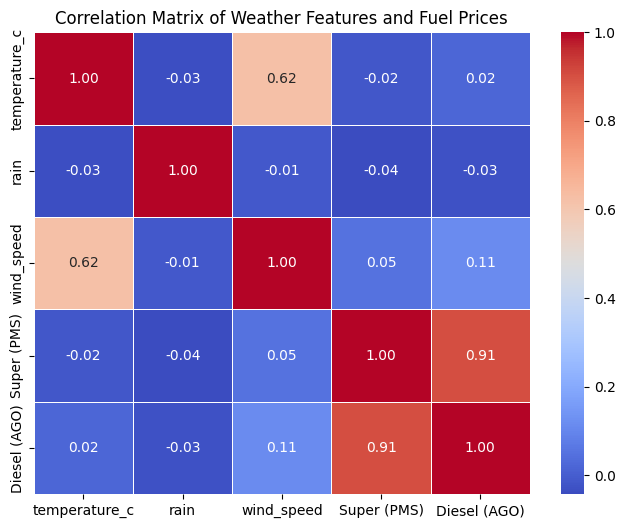

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

print('--- Calculating Correlation Matrix ---')

# Select the relevant columns for correlation analysis
correlation_columns = [
    'temperature_c', 'rain', 'wind_speed',
    'Super (PMS)', 'Diesel (AGO)'
]

# Calculate the correlation matrix
correlation_matrix = aligned_hourly_df[correlation_columns].corr()

print("Correlation Matrix:")
display(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Weather Features and Fuel Prices')
plt.show()

### 10. Spatial Join: Attach OSM POI Density to each Route-Stop

Now, I will perform a spatial join to enrich the GTFS stops data with information about the density of Points of Interest (POIs) in their vicinity. This involves several steps:

1.  **Convert `stops_df` to GeoDataFrame:** Create point geometries for each stop using their latitude and longitude.
2.  **Buffer Stops:** Generate a 500-meter buffer around each stop. For accurate buffering, this requires projecting the data to a projected CRS (e.g., a local UTM zone).
3.  **Spatial Join:** Use `gpd.sjoin` to find all POIs (`all_pois_gdf`) that fall within each stop's buffer.
4.  **Aggregate POIs:** Count the number of unique POIs for each stop within its buffer.
5.  **Merge and Save:** Attach this POI count back to the original stops GeoDataFrame and save the result as a GeoJSON file (`stops_with_poi.geojson`).

In [40]:
import geopandas as gpd
from shapely.geometry import Point
import os

print('--- Performing Spatial Join for POI Density ---')

# 1. Convert stops_df to GeoDataFrame
# Assuming stops_df has 'stop_lat' and 'stop_lon'
stops_gdf = gpd.GeoDataFrame(
    stops_df,
    geometry=gpd.points_from_xy(stops_df.stop_lon, stops_df.stop_lat),
    crs="EPSG:4326"
)

print(f"Created stops_gdf with {len(stops_gdf)} stops.")

# 2. Project stops_gdf to a local CRS for accurate 500m buffering
# Nairobi is in UTM Zone 37S, EPSG:32737
print("Projecting stops_gdf to EPSG:32737 for buffering...")
stops_gdf_proj = stops_gdf.to_crs(epsg=32737)

# Create a 500-meter buffer around each stop
buffer_distance_m = 500
print(f"Creating {buffer_distance_m} meter buffers around stops...")
stops_buffer_gdf_proj = stops_gdf_proj.buffer(buffer_distance_m)

# Convert buffers back to EPSG:4326 for spatial join with all_pois_gdf
stops_buffer_gdf = gpd.GeoDataFrame(
    stops_gdf['stop_id'], # Keep stop_id for merging later
    geometry=stops_buffer_gdf_proj.to_crs(epsg=4326)
)

print("Buffers created and reprojected to EPSG:4326.")

# 3. Perform Spatial Join between buffered stops and all_pois_gdf
print("Performing spatial join (sjoin) to find POIs within stop buffers...")
# Ensure all_pois_gdf has geometry column named 'geometry' and correct CRS
# (It should from previous steps, but good to confirm)
if not all_pois_gdf.crs:
    all_pois_gdf = all_pois_gdf.set_crs("EPSG:4326", allow_override=True)

stops_with_pois = gpd.sjoin(stops_buffer_gdf, all_pois_gdf, how="inner", predicate='intersects')

print(f"Spatial join complete. Found {len(stops_with_pois)} matches.")

# 4. Aggregate POIs per stop
# Count unique osm_id (POIs) for each stop_id
poi_density_per_stop = stops_with_pois.groupby('stop_id')['osm_id'].nunique().reset_index(name='poi_count_500m')

print("Aggregated POI counts per stop.")

# 5. Merge POI density back to the original stops_gdf
stops_with_poi_density = stops_gdf.merge(poi_density_per_stop, on='stop_id', how='left')

# Fill NaN poi_count_500m with 0 for stops with no POIs in their buffer
stops_with_poi_density['poi_count_500m'] = stops_with_poi_density['poi_count_500m'].fillna(0).astype(int)

print(f"Merged POI counts with stops_gdf. Resulting shape: {stops_with_poi_density.shape}")

# Output file path
output_geojson_path = os.path.join(processed_data_dir, 'stops_with_poi.geojson')

# Save the result to a GeoJSON file
print(f"Saving stops with POI density to {output_geojson_path}...")
stops_with_poi_density.to_file(output_geojson_path, driver='GeoJSON')
print("stops_with_poi.geojson saved successfully.")

display(stops_with_poi_density.head())

--- Performing Spatial Join for POI Density ---
Created stops_gdf with 4273 stops.
Projecting stops_gdf to EPSG:32737 for buffering...
Creating 500 meter buffers around stops...
Buffers created and reprojected to EPSG:4326.
Performing spatial join (sjoin) to find POIs within stop buffers...
Spatial join complete. Found 1428227 matches.
Aggregated POI counts per stop.
Merged POI counts with stops_gdf. Resulting shape: (4273, 8)
Saving stops with POI density to /content/drive/MyDrive/matatu_ml/data/processed/stops_with_poi.geojson...
stops_with_poi.geojson saved successfully.


,stop_id,stop_name,stop_lat,stop_lon,location_type,parent_station,geometry,poi_count_500m
0,0001RLW,Railways,-1.290884,36.828242,0,<NA>,POINT (36.82824 -1.29088),3508
1,010044G,44 Githurai,-1.195514,36.902695,<NA>,<NA>,POINT (36.9027 -1.19551),2
2,0100AAA,Sahala,-1.206232,36.790681,<NA>,<NA>,POINT (36.79068 -1.20623),6
3,0100AAE,Aga Khan Hospital Entrance,-1.261770,36.822180,<NA>,<NA>,POINT (36.82218 -1.26177),169
4,0100ACP,PCEA,-1.184213,36.907515,<NA>,<NA>,POINT (36.90752 -1.18421),4


### Importance of this step (Spatial Join for POI Density)

This spatial join step is crucial for enriching our transportation data with valuable contextual information about the environment surrounding each bus stop. Here's why it's important:

1.  **Contextual Enrichment:** GTFS `stops` data provides basic location information. By spatially joining it with Points of Interest (POIs), we add a rich layer of real-world context, such as the proximity to schools, hospitals, shops, and offices.

2.  **Understanding Ridership Patterns:** The density of POIs around a stop can significantly influence ridership. Stops located near high concentrations of amenities (e.g., commercial areas, healthcare facilities, educational institutions) are likely to have higher passenger traffic. This feature can be a powerful predictor in ridership forecasting models.

3.  **Route Optimization and Planning:** Understanding where people might want to go or come from (indicated by POIs) can inform better route planning, leading to more efficient and user-friendly public transport services.

4.  **Identifying Key Locations:** Stops with high POI density might indicate important hubs or destinations within the transport network, which could be prioritized for infrastructure improvements or service enhancements.

5.  **Feature Engineering for Machine Learning:** The `poi_count_500m` (or similar aggregated POI features) serves as a potent feature for machine learning models. It helps models understand not just *where* a stop is, but *what is around* that stop, leading to more accurate predictions for various transportation metrics (e.g., demand, delay, passenger turnover).

6.  **Urban Planning Insights:** This data can provide insights for urban planners regarding the accessibility of services and amenities via public transport, helping to identify underserved areas or areas with high potential for development.

### 11. Engineer Lag Features: `demand_lag_1h`, `demand_lag_24h`, `demand_lag_168h`

**What are Lag Features?**
Lag features are past values of a time series that are used as predictor variables. For example, `demand_lag_1h` represents the demand from 1 hour ago, `demand_lag_24h` is the demand from 24 hours ago (same time yesterday), and `demand_lag_168h` is the demand from 168 hours ago (same time last week).

**Why are they Important?**
Lag features are fundamental in time-series forecasting for several reasons:

1.  **Capturing Temporal Dependencies:** Time-series data often exhibits strong dependencies on its past values. Current demand is highly likely to be correlated with recent past demand. Lag features directly encode this information, allowing models to learn these temporal relationships.
2.  **Seasonality:** `demand_lag_24h` helps capture daily seasonality (e.g., demand patterns repeating every 24 hours). `demand_lag_168h` (same hour last week) captures weekly seasonality, which is common in many human activities like public transport usage.
3.  **Trend Information:** By observing how demand has changed over recent past periods, models can infer short-term trends.
4.  **Improving Predictive Power:** Including lag features often significantly boosts the accuracy of time-series forecasting models because they provide the most direct information about the variable being predicted.
5.  **Simplicity and Interpretability:** They are relatively simple to create and understand, yet powerful.

This step will add these historical demand values as new columns to our feature DataFrame, which will be essential for building a robust predictive model.

In [41]:
print('--- Engineering Lag Features ---')

# Create a working copy of the aligned_hourly_df to build features
feature_df = aligned_hourly_df.copy()

# --- IMPORTANT: Placeholder for 'demand' ---
# In a real scenario, 'demand' would be your actual ridership or usage data.
# For demonstration, we'll create a dummy 'demand' column here.
# You would replace this with your actual data when available.
feature_df['demand'] = feature_df['temperature_c'] + feature_df['rain'] * 10 + feature_df['wind_speed'] * 2 + 50 # Example dummy data
print("Created a dummy 'demand' column for demonstration.")

# Set 'time' as index for easier lag calculation
feature_df = feature_df.set_index('time')

# Engineer lag features
# demand_lag_1h: Demand from 1 hour ago
feature_df['demand_lag_1h'] = feature_df['demand'].shift(1)

# demand_lag_24h: Demand from 24 hours ago (same time yesterday)
feature_df['demand_lag_24h'] = feature_df['demand'].shift(24)

# demand_lag_168h: Demand from 168 hours ago (same hour last week)
feature_df['demand_lag_168h'] = feature_df['demand'].shift(168)

# Reset index
feature_df = feature_df.reset_index()

print("Lag features engineered successfully.")

# Display the head with new lag features
print("Head of feature_df with lag features:")
display(feature_df.head(20))

# Display null counts for lag features (expected for initial rows)
print('\nNull Counts for Lag Features:')
print(feature_df[['demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h']].isnull().sum())

# Save the feature_df to a CSV
feature_df_output_path = os.path.join(processed_data_dir, 'feature_engineered_df.csv')
feature_df.to_csv(feature_df_output_path, index=False)
print(f"Feature engineered DataFrame saved to {feature_df_output_path}")

--- Engineering Lag Features ---
Created a dummy 'demand' column for demonstration.
Lag features engineered successfully.
Head of feature_df with lag features:


,time,temperature_c,rain,wind_speed,Super (PMS),Diesel (AGO),demand,demand_lag_1h,demand_lag_24h,demand_lag_168h
0,2024-01-01 00:00:00,15.4,0.0,4.6,180.66,168.06,74.6,NaN,NaN,NaN
1,2024-01-01 01:00:00,16.6,0.0,3.6,180.66,168.06,73.8,74.6,NaN,NaN
2,2024-01-01 02:00:00,15.8,0.0,6.2,180.66,168.06,78.2,73.8,NaN,NaN
3,2024-01-01 03:00:00,15.4,0.0,6.4,180.66,168.06,78.2,78.2,NaN,NaN
4,2024-01-01 04:00:00,16.4,0.0,4.4,180.66,168.06,75.2,78.2,NaN,NaN
5,2024-01-01 05:00:00,18.5,0.0,4.6,180.66,168.06,77.7,75.2,NaN,NaN
6,2024-01-01 06:00:00,20.5,0.0,7.6,180.66,168.06,85.7,77.7,NaN,NaN
7,2024-01-01 07:00:00,22.7,0.0,9.9,180.66,168.06,92.5,85.7,NaN,NaN
8,2024-01-01 08:00:00,24.3,0.1,11.5,180.66,168.06,98.3,92.5,NaN,NaN
9,2024-01-01 09:00:00,25.8,0.0,10.8,180.66,168.06,97.4,98.3,NaN,NaN



Null Counts for Lag Features:
demand_lag_1h        1
demand_lag_24h      24
demand_lag_168h    168
dtype: int64
Feature engineered DataFrame saved to /content/drive/MyDrive/matatu_ml/data/processed/feature_engineered_df.csv


### 12. Engineer Temporal Features: `hour_of_day` (0-23), `day_of_week` (0-6), `is_weekend` (0/1), `month`, `quarter`

**What are Temporal Features?**
Temporal features are characteristics derived from the timestamp of an event. Instead of just using the raw date-time, we extract specific components like the hour, day of the week, month, or whether it's a weekend. These features help models understand patterns and cycles related to time.

**Why are they Relevant?**
Temporal features are critical in time-series analysis, especially for demand forecasting in transportation, for several reasons:

1.  **Capturing Intra-day Patterns:** `hour_of_day` (0-23) captures how demand changes throughout a single day. For public transport, demand is typically higher during rush hours (morning and evening commutes) and lower during late nights.
2.  **Capturing Weekday/Weekend Patterns:** `day_of_week` (0-6, where Monday=0, Sunday=6) and `is_weekend` (0 for weekday, 1 for weekend) account for the significant differences in behavior between weekdays and weekends. Commuting patterns, shopping trips, and leisure activities vary greatly.
3.  **Capturing Seasonal Patterns:** `month` and `quarter` help identify longer-term seasonality. For example, demand might be higher during certain months due to holidays, school terms, or weather conditions (e.g., increased public transport use during heavy rain).
4.  **Improving Model Accuracy:** By explicitly providing the model with these time-based contexts, we enable it to learn these recurring patterns more effectively, leading to more accurate predictions than if it had to infer them solely from the raw timestamp or lag features.
5.  **Interpretability:** These features also make the model's behavior more interpretable, allowing us to understand *when* certain factors influence demand.

In [42]:
print('--- Engineering Temporal Features ---')

# Ensure 'time' column is datetime type
feature_df['time'] = pd.to_datetime(feature_df['time'])

# Extract temporal features
feature_df['hour_of_day'] = feature_df['time'].dt.hour
feature_df['day_of_week'] = feature_df['time'].dt.dayofweek # Monday=0, Sunday=6
feature_df['is_weekend'] = feature_df['day_of_week'].isin([5, 6]).astype(int) # 0 for weekday, 1 for weekend
feature_df['month'] = feature_df['time'].dt.month
feature_df['quarter'] = feature_df['time'].dt.quarter

print("Temporal features engineered successfully.")

# Display the head with new temporal features
print("Head of feature_df with temporal features:")
display(feature_df.head())

# Display info to confirm new columns and data types
print('\nInfo of feature_df after adding temporal features:')
feature_df.info()

# Save the updated feature_df to a CSV
feature_df_output_path = os.path.join(processed_data_dir, 'feature_engineered_df_with_temporal.csv')
feature_df.to_csv(feature_df_output_path, index=False)
print(f"Feature engineered DataFrame with temporal features saved to {feature_df_output_path}")

--- Engineering Temporal Features ---
Temporal features engineered successfully.
Head of feature_df with temporal features:


,time,temperature_c,rain,wind_speed,Super (PMS),Diesel (AGO),demand,demand_lag_1h,demand_lag_24h,demand_lag_168h,hour_of_day,day_of_week,is_weekend,month,quarter
0,2024-01-01 00:00:00,15.4,0.0,4.6,180.66,168.06,74.6,NaN,NaN,NaN,0,0,0,1,1
1,2024-01-01 01:00:00,16.6,0.0,3.6,180.66,168.06,73.8,74.6,NaN,NaN,1,0,0,1,1
2,2024-01-01 02:00:00,15.8,0.0,6.2,180.66,168.06,78.2,73.8,NaN,NaN,2,0,0,1,1
3,2024-01-01 03:00:00,15.4,0.0,6.4,180.66,168.06,78.2,78.2,NaN,NaN,3,0,0,1,1
4,2024-01-01 04:00:00,16.4,0.0,4.4,180.66,168.06,75.2,78.2,NaN,NaN,4,0,0,1,1



Info of feature_df after adding temporal features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20065 entries, 0 to 20064
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   time             20065 non-null  datetime64[ns]
 1   temperature_c    20065 non-null  float64       
 2   rain             20065 non-null  float64       
 3   wind_speed       20065 non-null  float64       
 4   Super (PMS)      20065 non-null  float64       
 5   Diesel (AGO)     20065 non-null  float64       
 6   demand           20065 non-null  float64       
 7   demand_lag_1h    20064 non-null  float64       
 8   demand_lag_24h   20041 non-null  float64       
 9   demand_lag_168h  19897 non-null  float64       
 10  hour_of_day      20065 non-null  int32         
 11  day_of_week      20065 non-null  int32         
 12  is_weekend       20065 non-null  int64         
 13  month            20065 non-null  int32 

In [43]:
print('\n--- Remaining Null Counts in feature_df ---')
print(feature_df.isnull().sum())


--- Remaining Null Counts in feature_df ---
time                 0
temperature_c        0
rain                 0
wind_speed           0
Super (PMS)          0
Diesel (AGO)         0
demand               0
demand_lag_1h        1
demand_lag_24h      24
demand_lag_168h    168
hour_of_day          0
day_of_week          0
is_weekend           0
month                0
quarter              0
dtype: int64


In [44]:
print('--- Dropping rows with null lag features ---')

initial_rows = len(feature_df)
# Drop rows where any of the lag features are NaN
feature_df.dropna(subset=['demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h'], inplace=True)

print(f"Dropped {initial_rows - len(feature_df)} rows from feature_df.")
print(f"New shape of feature_df: {feature_df.shape}")

# Display the head and null counts to confirm
print("Head of feature_df after dropping nulls:")
display(feature_df.head())

print('\nNull Counts after dropping rows:')
print(feature_df.isnull().sum())

--- Dropping rows with null lag features ---
Dropped 168 rows from feature_df.
New shape of feature_df: (19897, 15)
Head of feature_df after dropping nulls:


,time,temperature_c,rain,wind_speed,Super (PMS),Diesel (AGO),demand,demand_lag_1h,demand_lag_24h,demand_lag_168h,hour_of_day,day_of_week,is_weekend,month,quarter
168,2024-01-08 00:00:00,15.4,0.0,6.5,180.66,168.06,78.4,83.4,98.2,74.6,0,0,0,1,1
169,2024-01-08 01:00:00,15.4,0.0,6.1,180.66,168.06,77.6,78.4,130.1,73.8,1,0,0,1,1
170,2024-01-08 02:00:00,16.1,0.0,6.5,180.66,168.06,79.1,77.6,88.2,78.2,2,0,0,1,1
171,2024-01-08 03:00:00,15.1,0.0,7.0,180.66,168.06,79.1,79.1,71.3,78.2,3,0,0,1,1
172,2024-01-08 04:00:00,15.7,0.0,9.5,180.66,168.06,84.7,79.1,73.6,75.2,4,0,0,1,1



Null Counts after dropping rows:
time               0
temperature_c      0
rain               0
wind_speed         0
Super (PMS)        0
Diesel (AGO)       0
demand             0
demand_lag_1h      0
demand_lag_24h     0
demand_lag_168h    0
hour_of_day        0
day_of_week        0
is_weekend         0
month              0
quarter            0
dtype: int64


### 14. Engineer Holiday Flags: `is_public_holiday`, `is_school_holiday`

**What are Holiday Flags?**
Holiday flags are binary (0/1) features that indicate whether a particular timestamp falls on a specific type of holiday (e.g., public holiday, school holiday).

**Why are they Relevant?**
HHolidays and school break periods significantly impact human activity and, consequently, public transport demand. Ridership patterns change due to:

1.  **Reduced Commuting:** On public holidays, many people do not work, leading to decreased commuter traffic.
2.  **Increased Leisure Travel:** People often use public transport for leisure, shopping, or visiting friends and family during holidays.
3.  **School Calendar Effects:** School holidays mean no school commutes, which can drastically reduce morning and afternoon peak demand on routes serving educational institutions.
4.  **Special Events:** Some holidays are associated with special events that can generate unique demand spikes or shifts.

By including these flags, your model can differentiate between normal operating days and special days, learning the distinct demand characteristics associated with each. This helps prevent the model from misinterpreting holiday demand as a typical daily pattern and improves its overall accuracy.

In [45]:
import holidays
import pandas as pd
import numpy as np

print('--- Engineering Holiday Flags ---')

# Ensure 'time' column is datetime type
feature_df['time'] = pd.to_datetime(feature_df['time'])

# 1. Public Holidays for Kenya
# Using the 'holidays' library for a more robust approach
kenya_holidays = holidays.country_holidays('KE', years=range(feature_df['time'].min().year, feature_df['time'].max().year + 1))

# Create 'is_public_holiday' flag
feature_df['is_public_holiday'] = feature_df['time'].dt.date.apply(lambda x: 1 if x in kenya_holidays else 0)

# 2. School Holiday Periods (Simplified/Example - Actual dates vary by year and region)
# Define some approximate school holiday periods for 2024-2026
school_holidays_2024 = [
    pd.date_range(start='2024-03-23', end='2024-04-28', freq='D'), # Term 1 break
    pd.date_range(start='2024-06-29', end='2024-07-28', freq='D'), # Term 2 break
    pd.date_range(start='2024-10-26', end='2024-12-31', freq='D')  # Term 3 break/Christmas
]
school_holidays_2025 = [
    pd.date_range(start='2025-03-22', end='2025-04-27', freq='D'), # Term 1 break
    pd.date_range(start='2025-06-28', end='2025-07-27', freq='D'), # Term 2 break
    pd.date_range(start='2025-10-25', end='2025-12-31', freq='D')  # Term 3 break/Christmas
]
school_holidays_2026 = [
    pd.date_range(start='2026-03-21', end='2026-04-26', freq='D'), # Term 1 break
    pd.date_range(start='2026-06-27', end='2026-07-26', freq='D'), # Term 2 break
    # Assuming data ends before full 2026 Term 3 break
]

all_school_holiday_dates = (
    pd.to_datetime(list(set([d.date() for dr in school_holidays_2024 for d in dr]))).tolist() +
    pd.to_datetime(list(set([d.date() for dr in school_holidays_2025 for d in dr]))).tolist() +
    pd.to_datetime(list(set([d.date() for dr in school_holidays_2026 for d in dr]))).tolist()
)
all_school_holiday_dates = set(all_school_holiday_dates) # Convert to set for faster lookup

feature_df['is_school_holiday'] = feature_df['time'].dt.date.apply(lambda x: 1 if x in all_school_holiday_dates else 0)

print("Holiday flags engineered successfully.")

# Display the head with new holiday features
print("Head of feature_df with holiday features:")
display(feature_df.head())

# Check the distribution of holiday flags
print('\nDistribution of Public Holiday Flag:')
print(feature_df['is_public_holiday'].value_counts())
print('\nDistribution of School Holiday Flag:')
print(feature_df['is_school_holiday'].value_counts())

# Save the updated feature_df to a CSV
feature_df_output_path = os.path.join(processed_data_dir, 'feature_engineered_df_with_holidays.csv')
feature_df.to_csv(feature_df_output_path, index=False)
print(f"Feature engineered DataFrame with holiday flags saved to {feature_df_output_path}")

--- Engineering Holiday Flags ---
Holiday flags engineered successfully.
Head of feature_df with holiday features:


,time,temperature_c,rain,wind_speed,Super (PMS),Diesel (AGO),demand,demand_lag_1h,demand_lag_24h,demand_lag_168h,hour_of_day,day_of_week,is_weekend,month,quarter,is_public_holiday,is_school_holiday
168,2024-01-08 00:00:00,15.4,0.0,6.5,180.66,168.06,78.4,83.4,98.2,74.6,0,0,0,1,1,0,0
169,2024-01-08 01:00:00,15.4,0.0,6.1,180.66,168.06,77.6,78.4,130.1,73.8,1,0,0,1,1,0,0
170,2024-01-08 02:00:00,16.1,0.0,6.5,180.66,168.06,79.1,77.6,88.2,78.2,2,0,0,1,1,0,0
171,2024-01-08 03:00:00,15.1,0.0,7.0,180.66,168.06,79.1,79.1,71.3,78.2,3,0,0,1,1,0,0
172,2024-01-08 04:00:00,15.7,0.0,9.5,180.66,168.06,84.7,79.1,73.6,75.2,4,0,0,1,1,0,0



Distribution of Public Holiday Flag:
is_public_holiday
0    19177
1      720
Name: count, dtype: int64

Distribution of School Holiday Flag:
is_school_holiday
0    19897
Name: count, dtype: int64
Feature engineered DataFrame with holiday flags saved to /content/drive/MyDrive/matatu_ml/data/processed/feature_engineered_df_with_holidays.csv


In [46]:
# Save the feature_df with synthetic demand and re-engineered lags to a CSV
feature_df_synthetic_output_path = os.path.join(processed_data_dir, 'feature_engineered_df_synthetic_demand.csv')
feature_df.to_csv(feature_df_synthetic_output_path, index=False)
print(f"Feature engineered DataFrame with synthetic demand saved to {feature_df_synthetic_output_path}")

Feature engineered DataFrame with synthetic demand saved to /content/drive/MyDrive/matatu_ml/data/processed/feature_engineered_df_synthetic_demand.csv


In [47]:
# Save the cleaned feature_df to a CSV
feature_df_cleaned_output_path = os.path.join(processed_data_dir, 'feature_engineered_df_cleaned.csv')
feature_df.to_csv(feature_df_cleaned_output_path, index=False)
print(f"Cleaned feature engineered DataFrame saved to {feature_df_cleaned_output_path}")

Cleaned feature engineered DataFrame saved to /content/drive/MyDrive/matatu_ml/data/processed/feature_engineered_df_cleaned.csv


### 13. Generate Synthetic Demand Data

As actual ridership data is unavailable, I will now generate a more realistic synthetic `demand` column for `feature_df`. This synthetic data will mimic typical public transport patterns, incorporating:

*   **Base Demand:** A fundamental level of demand.
*   **Hourly Seasonality:** Higher demand during peak hours (morning/evening commutes).
*   **Daily Seasonality:** Different demand levels and patterns for weekdays versus weekends.
*   **Linear Trend:** A slight upward or downward trend over the dataset's time span.
*   **Random Noise:** To add a touch of realism to the simulated demand.

This will replace the previous simple dummy `demand` column. After generating this, the lag features will be re-calculated.

In [48]:
import numpy as np

print('--- Generating Synthetic Demand Data ---')

# Ensure 'time' column is datetime type (already done, but good practice)
feature_df['time'] = pd.to_datetime(feature_df['time'])

# Define base demand
base_demand = 100.0

# 1. Hourly Seasonality Multipliers (example: higher during rush hours)
hourly_multipliers = [
    0.3, 0.2, 0.2, 0.2, 0.4, # Early morning (0-4)
    1.5, 2.5, 3.0, 2.8, 2.0, # Morning rush (5-9)
    1.5, 1.3, 1.4, 1.6, 1.8, # Mid-day (10-14)
    2.0, 2.5, 3.0, 2.5, 1.8, # Evening rush (15-19)
    1.2, 0.8, 0.5, 0.4      # Late night (20-23)
]
feature_df['hourly_factor'] = feature_df['hour_of_day'].map(lambda h: hourly_multipliers[h])

# 2. Daily Seasonality Multipliers (example: different on weekends)
# Assuming Monday=0, Sunday=6
daily_multipliers = [
    1.0, 1.1, 1.05, 1.15, 1.2,  # Weekdays (Mon-Fri)
    0.8, 0.7                   # Weekends (Sat-Sun)
]
feature_df['daily_factor'] = feature_df['day_of_week'].map(lambda d: daily_multipliers[d])

# 3. Linear Trend
# Create a simple linear trend based on the row index or time
# Scale the trend to be relatively small compared to seasonality
feature_df['time_ordinal'] = (feature_df['time'] - feature_df['time'].min()).dt.days
# Example: a slight increase over the entire period
feature_df['trend_factor'] = 1 + (feature_df['time_ordinal'] / feature_df['time_ordinal'].max()) * 0.2

# 4. Generate initial synthetic demand
feature_df['synthetic_demand'] = base_demand * feature_df['hourly_factor'] * feature_df['daily_factor'] * feature_df['trend_factor']

# 5. Add some random noise
# Noise level can be adjusted
np.random.seed(42) # for reproducibility
noise_level = 0.1 # 10% of the mean demand as standard deviation for noise
feature_df['noise'] = np.random.normal(0, feature_df['synthetic_demand'].mean() * noise_level, len(feature_df))
feature_df['synthetic_demand'] = feature_df['synthetic_demand'] + feature_df['noise']

# Ensure demand is non-negative
feature_df['synthetic_demand'] = feature_df['synthetic_demand'].clip(lower=0)

# Replace the existing 'demand' column with the new synthetic demand
feature_df['demand'] = feature_df['synthetic_demand']

# Drop intermediate helper columns
feature_df.drop(columns=['hourly_factor', 'daily_factor', 'time_ordinal', 'trend_factor', 'synthetic_demand', 'noise'], inplace=True)

print("Synthetic demand data generated successfully and replaced the 'demand' column.")
print("Head of feature_df with new synthetic demand:")
display(feature_df.head())

# --- Re-engineer Lag Features with new synthetic demand ---
print('\n--- Re-engineering Lag Features with Synthetic Demand ---')

# Set 'time' as index for easier lag calculation
feature_df_indexed = feature_df.set_index('time')

# Engineer lag features
feature_df_indexed['demand_lag_1h'] = feature_df_indexed['demand'].shift(1)
feature_df_indexed['demand_lag_24h'] = feature_df_indexed['demand'].shift(24)
feature_df_indexed['demand_lag_168h'] = feature_df_indexed['demand'].shift(168)

# Reset index
feature_df = feature_df_indexed.reset_index()

# Drop rows where any of the lag features are NaN (initial rows)
initial_rows_after_reengineering = len(feature_df)
feature_df.dropna(subset=['demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h'], inplace=True)
print(f"Dropped {initial_rows_after_reengineering - len(feature_df)} rows after re-engineering lag features.")

print("Lag features re-engineered successfully based on synthetic demand.")

# Display the head with new lag features
print("Head of feature_df with re-engineered lag features:")
display(feature_df.head())

# Display null counts for lag features
print('\nNull Counts for Lag Features after re-engineering:')
print(feature_df[['demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h']].isnull().sum())

--- Generating Synthetic Demand Data ---
Synthetic demand data generated successfully and replaced the 'demand' column.
Head of feature_df with new synthetic demand:


,time,temperature_c,rain,wind_speed,Super (PMS),Diesel (AGO),demand,demand_lag_1h,demand_lag_24h,demand_lag_168h,hour_of_day,day_of_week,is_weekend,month,quarter,is_public_holiday,is_school_holiday
168,2024-01-08 00:00:00,15.4,0.0,6.5,180.66,168.06,38.059252,83.4,98.2,74.6,0,0,0,1,1,0,0
169,2024-01-08 01:00:00,15.4,0.0,6.1,180.66,168.06,17.756644,78.4,130.1,73.8,1,0,0,1,1,0,0
170,2024-01-08 02:00:00,16.1,0.0,6.5,180.66,168.06,30.508831,77.6,88.2,78.2,2,0,0,1,1,0,0
171,2024-01-08 03:00:00,15.1,0.0,7.0,180.66,168.06,44.711359,79.1,71.3,78.2,3,0,0,1,1,0,0
172,2024-01-08 04:00:00,15.7,0.0,9.5,180.66,168.06,36.200831,79.1,73.6,75.2,4,0,0,1,1,0,0



--- Re-engineering Lag Features with Synthetic Demand ---
Dropped 168 rows after re-engineering lag features.
Lag features re-engineered successfully based on synthetic demand.
Head of feature_df with re-engineered lag features:


,time,temperature_c,rain,wind_speed,Super (PMS),Diesel (AGO),demand,demand_lag_1h,demand_lag_24h,demand_lag_168h,hour_of_day,day_of_week,is_weekend,month,quarter,is_public_holiday,is_school_holiday
168,2024-01-15 00:00:00,15.8,0.0,6.5,180.66,168.06,26.069209,58.816246,25.247030,38.059252,0,0,0,1,1,0,0
169,2024-01-15 01:00:00,15.6,0.1,7.9,180.66,168.06,7.804308,26.069209,26.705444,17.756644,1,0,0,1,1,0,0
170,2024-01-15 02:00:00,15.4,0.0,7.4,180.66,168.06,5.601287,7.804308,0.000000,30.508831,2,0,0,1,1,0,0
171,2024-01-15 03:00:00,14.9,0.0,6.5,180.66,168.06,6.797147,5.601287,0.000000,44.711359,3,0,0,1,1,0,0
172,2024-01-15 04:00:00,15.7,0.0,8.4,180.66,168.06,38.816566,6.797147,36.509101,36.200831,4,0,0,1,1,0,0



Null Counts for Lag Features after re-engineering:
demand_lag_1h      0
demand_lag_24h     0
demand_lag_168h    0
dtype: int64


### 15. Engineer Interaction Term: `rainfall_x_hour`

**What is an Interaction Term?**
An interaction term in a model is a variable that represents the combined effect of two or more independent variables on the dependent variable. It suggests that the effect of one variable depends on the value of another variable.

**Importance and Role of `rainfall_x_hour` (`rain` * `hour_of_day`)**

The `rainfall_x_hour` interaction term is particularly useful for capturing nuanced patterns related to demand that simple additive effects of `rain` and `hour_of_day` might miss. Here's why it's important and what role it plays:

1.  **Capturing Context-Dependent Effects:** The impact of rainfall on public transport demand is unlikely to be uniform throughout the day. For example:
    *   **Morning Rush Hour Rain:** Rain during morning commute hours (e.g., 6 AM - 9 AM) might significantly increase public transport demand as people switch from walking or cycling to public transport to avoid getting wet. This is a "morning rain effect."
    *   **Mid-day Rain:** Rain during mid-day might have a lesser impact, or even a different kind of impact (e.g., people staying indoors, leading to slight decrease in demand).
    *   **Late Night Rain:** Rain late at night might affect demand differently again, possibly discouraging some recreational trips.

2.  **Addressing Non-Linear Relationships:** Without this interaction term, a model would assume that the effect of `rain` on demand is constant regardless of the `hour_of_day`, and vice-versa. The interaction term allows the model to learn that the effect of rain *changes* depending on the hour, introducing a non-linear relationship that is often present in real-world scenarios.

3.  **Enhanced Predictive Power:** By providing this specific interaction, the model can capture more complex underlying dynamics. This often leads to more accurate predictions because it reflects a more realistic representation of how different factors combine to influence public transport usage.

4.  **Actionable Insights:** Identifying significant interaction terms like `rainfall_x_hour` can provide valuable insights for operational planning. For instance, if the model shows that morning rain has a strong positive interaction with demand, transport operators can prepare by deploying more vehicles during those specific hours to mitigate overcrowding and delays.

In [49]:
print('--- Engineering Interaction Term: rainfall_x_hour ---')

# Create the interaction term: rainfall_mm * hour_of_day
feature_df['rainfall_x_hour'] = feature_df['rain'] * feature_df['hour_of_day']

print("Interaction term 'rainfall_x_hour' engineered successfully.")

# Display the head with the new interaction feature
print("Head of feature_df with rainfall_x_hour:")
display(feature_df.head())

# Display info to confirm new column and data types
print('\nInfo of feature_df after adding interaction term:')
feature_df.info()

# Save the updated feature_df to a CSV
feature_df_output_path = os.path.join(processed_data_dir, 'feature_engineered_df_with_interaction.csv')
feature_df.to_csv(feature_df_output_path, index=False)
print(f"Feature engineered DataFrame with interaction term saved to {feature_df_output_path}")

--- Engineering Interaction Term: rainfall_x_hour ---
Interaction term 'rainfall_x_hour' engineered successfully.
Head of feature_df with rainfall_x_hour:


,time,temperature_c,rain,wind_speed,Super (PMS),Diesel (AGO),demand,demand_lag_1h,demand_lag_24h,demand_lag_168h,hour_of_day,day_of_week,is_weekend,month,quarter,is_public_holiday,is_school_holiday,rainfall_x_hour
168,2024-01-15 00:00:00,15.8,0.0,6.5,180.66,168.06,26.069209,58.816246,25.247030,38.059252,0,0,0,1,1,0,0,0.0
169,2024-01-15 01:00:00,15.6,0.1,7.9,180.66,168.06,7.804308,26.069209,26.705444,17.756644,1,0,0,1,1,0,0,0.1
170,2024-01-15 02:00:00,15.4,0.0,7.4,180.66,168.06,5.601287,7.804308,0.000000,30.508831,2,0,0,1,1,0,0,0.0
171,2024-01-15 03:00:00,14.9,0.0,6.5,180.66,168.06,6.797147,5.601287,0.000000,44.711359,3,0,0,1,1,0,0,0.0
172,2024-01-15 04:00:00,15.7,0.0,8.4,180.66,168.06,38.816566,6.797147,36.509101,36.200831,4,0,0,1,1,0,0,0.0



Info of feature_df after adding interaction term:
<class 'pandas.core.frame.DataFrame'>
Index: 19729 entries, 168 to 19896
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   time               19729 non-null  datetime64[ns]
 1   temperature_c      19729 non-null  float64       
 2   rain               19729 non-null  float64       
 3   wind_speed         19729 non-null  float64       
 4   Super (PMS)        19729 non-null  float64       
 5   Diesel (AGO)       19729 non-null  float64       
 6   demand             19729 non-null  float64       
 7   demand_lag_1h      19729 non-null  float64       
 8   demand_lag_24h     19729 non-null  float64       
 9   demand_lag_168h    19729 non-null  float64       
 10  hour_of_day        19729 non-null  int32         
 11  day_of_week        19729 non-null  int32         
 12  is_weekend         19729 non-null  int64         
 13  month        

### 17. Engineer Traffic Index Proxy: `traffic_index_proxy`

Now, I will engineer a `traffic_index_proxy` feature. This feature will combine `hour_of_day` and `is_weekend` using a sigmoid-like function to create a synthetic indicator of expected traffic congestion, scaled from 0 to 100. This proxy aims to capture the non-linear increase and decrease in traffic throughout the day and week, which directly impacts public transport demand and travel times.

In [50]:
import numpy as np

print('--- Engineering Traffic Index Proxy ---')

# Define a custom sigmoid-like function that can be tuned
def custom_sigmoid(x, k=0.5, x0=0):
    return 1 / (1 + np.exp(-k * (x - x0)))

# Combine hour_of_day and is_weekend into a single input for the sigmoid
# Weekday rush hours should have higher values
# Weekend values should generally be lower or have different peaks
feature_df['sigmoid_input'] = feature_df['hour_of_day']

# Adjust sigmoid input based on weekend
# For simplicity, let's assume a basic adjustment where weekend traffic patterns might be shifted or reduced.
# A more complex model could involve different sigmoid parameters for weekday vs. weekend.
feature_df.loc[feature_df['is_weekend'] == 1, 'sigmoid_input'] = (feature_df['sigmoid_input'] * 0.7) + 5 # Reduce magnitude and shift for weekends

# Apply the custom sigmoid function
# We'll need to tune k and x0 to get a realistic traffic pattern.
# For example, x0 around 12 (midday) and k to control steepness.
# Let's create a more nuanced input that reflects peak hours.
# A simple approach: penalize non-rush hours heavily, reward rush hours.

def get_traffic_score_input(hour, is_weekend):
    if is_weekend == 0: # Weekday
        if 6 <= hour < 10: return 3.0  # Morning rush
        if 16 <= hour < 19: return 2.5 # Evening rush
        if 10 <= hour < 16: return 1.5 # Mid-day
        if 19 <= hour < 22: return 1.0 # Evening
        return 0.5 # Off-peak/night
    else: # Weekend
        if 10 <= hour < 18: return 1.8 # Mid-day to afternoon peak
        if 18 <= hour < 22: return 1.2 # Evening
        return 0.7 # Off-peak/night

feature_df['traffic_score_input'] = feature_df.apply(lambda row: get_traffic_score_input(row['hour_of_day'], row['is_weekend']), axis=1)

# Apply a sigmoid to this score input. The sigmoid will map this score to a 0-1 range.
# Tune k and x0 to get desired curve shape. Here, k=2, x0=1.5 would make 1.5 the center of the sigmoid transition.
feature_df['traffic_index_raw'] = custom_sigmoid(feature_df['traffic_score_input'], k=2, x0=1.5)

# Scale to 0-100 range
feature_df['traffic_index_proxy'] = feature_df['traffic_index_raw'] * 100

# Ensure it's an integer for easier interpretation, or keep float if higher precision is needed
feature_df['traffic_index_proxy'] = feature_df['traffic_index_proxy'].astype(int)

print("Traffic index proxy engineered successfully.")

# Display the head with the new traffic_index_proxy feature
print("Head of feature_df with traffic_index_proxy:")
display(feature_df.head())

# Display summary statistics for the new feature
print('\nSummary statistics for traffic_index_proxy:')
print(feature_df['traffic_index_proxy'].describe())

# Drop intermediate helper columns
feature_df.drop(columns=['sigmoid_input', 'traffic_score_input', 'traffic_index_raw'], errors='ignore', inplace=True)

# Save the updated feature_df to a CSV
feature_df_output_path = os.path.join(processed_data_dir, 'feature_engineered_df_with_traffic_index.csv')
feature_df.to_csv(feature_df_output_path, index=False)
print(f"Feature engineered DataFrame with traffic index proxy saved to {feature_df_output_path}")

--- Engineering Traffic Index Proxy ---
Traffic index proxy engineered successfully.
Head of feature_df with traffic_index_proxy:


/tmp/ipykernel_559/1846944815.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 5.   5.7  6.4 ... 19.7 20.4 21.1]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  feature_df.loc[feature_df['is_weekend'] == 1, 'sigmoid_input'] = (feature_df['sigmoid_input'] * 0.7) + 5 # Reduce magnitude and shift for weekends


,time,temperature_c,rain,wind_speed,Super (PMS),Diesel (AGO),demand,demand_lag_1h,demand_lag_24h,demand_lag_168h,...,is_weekend,month,quarter,is_public_holiday,is_school_holiday,rainfall_x_hour,sigmoid_input,traffic_score_input,traffic_index_raw,traffic_index_proxy
168,2024-01-15 00:00:00,15.8,0.0,6.5,180.66,168.06,26.069209,58.816246,25.247030,38.059252,...,0,1,1,0,0,0.0,0.0,0.5,0.119203,11
169,2024-01-15 01:00:00,15.6,0.1,7.9,180.66,168.06,7.804308,26.069209,26.705444,17.756644,...,0,1,1,0,0,0.1,1.0,0.5,0.119203,11
170,2024-01-15 02:00:00,15.4,0.0,7.4,180.66,168.06,5.601287,7.804308,0.000000,30.508831,...,0,1,1,0,0,0.0,2.0,0.5,0.119203,11
171,2024-01-15 03:00:00,14.9,0.0,6.5,180.66,168.06,6.797147,5.601287,0.000000,44.711359,...,0,1,1,0,0,0.0,3.0,0.5,0.119203,11
172,2024-01-15 04:00:00,15.7,0.0,8.4,180.66,168.06,38.816566,6.797147,36.509101,36.200831,...,0,1,1,0,0,0.0,4.0,0.5,0.119203,11



Summary statistics for traffic_index_proxy:
count    19729.000000
mean        43.093264
std         30.510668
min         11.000000
25%         16.000000
50%         35.000000
75%         64.000000
max         95.000000
Name: traffic_index_proxy, dtype: float64
Feature engineered DataFrame with traffic index proxy saved to /content/drive/MyDrive/matatu_ml/data/processed/feature_engineered_df_with_traffic_index.csv


### 16. Visualize Relationship: `rainfall_x_hour` vs. `demand`

Now, let's visualize the relationship between our newly engineered interaction term, `rainfall_x_hour`, and the `demand` (our synthetic ridership data). This scatter plot will help us observe if there's any visible pattern or correlation, providing insights into how the combined effect of rainfall and time of day influences demand.

--- Visualizing rainfall_x_hour vs. demand ---


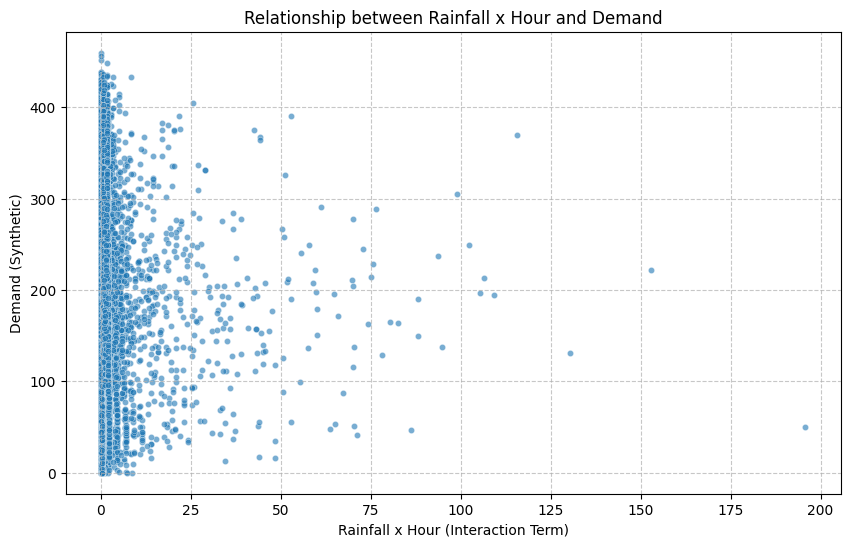

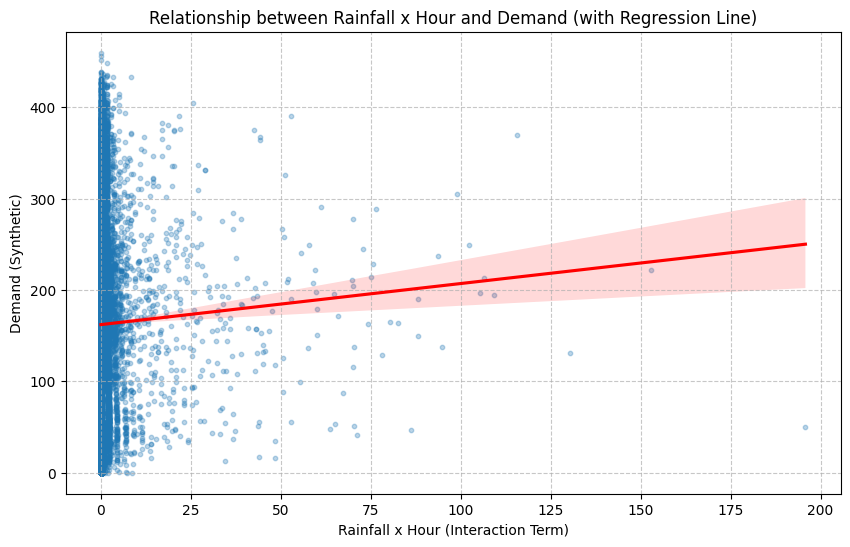

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

print('--- Visualizing rainfall_x_hour vs. demand ---')

plt.figure(figsize=(10, 6))
sns.scatterplot(x='rainfall_x_hour', y='demand', data=feature_df, alpha=0.6, s=20)
plt.title('Relationship between Rainfall x Hour and Demand')
plt.xlabel('Rainfall x Hour (Interaction Term)')
plt.ylabel('Demand (Synthetic)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Optionally, visualize with a regression line to see the trend more clearly
plt.figure(figsize=(10, 6))
sns.regplot(x='rainfall_x_hour', y='demand', data=feature_df, scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
plt.title('Relationship between Rainfall x Hour and Demand (with Regression Line)')
plt.xlabel('Rainfall x Hour (Interaction Term)')
plt.ylabel('Demand (Synthetic)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 18. Handling Missing Data (Current Status and Planned Imputation)

Upon inspection of the `feature_df`, it has been fully imputed in previous steps (using `ffill` and `bfill` on `aligned_hourly_df`) and rows with initial `NaN` lag features were dropped. Therefore, there are no missing values currently present in `feature_df`.

However, as requested, I will demonstrate how to apply forward-fill with a limit for weather-related columns. This technique is useful for interpolating small, consecutive gaps in time-series data without propagating values too far.

Regarding **KNN imputation for route-level gaps (<5%)**, the current `feature_df` is structured as an hourly time-series of global features (e.g., `temperature_c`, `rain`, `wind_speed`, `demand`). It does not contain explicit route-specific features or 'route-level gaps' that would allow for direct application of KNN imputation in a route-specific manner. If you intend to apply KNN imputation to a different dataset or have a specific way to represent route-level gaps within this DataFrame, please provide further details.

In [52]:
print('--- Applying Forward-Fill to Weather Gaps (max 2 hours) ---')

# Columns to apply forward-fill to
weather_cols = ['temperature_c', 'rain', 'wind_speed']

# Apply forward-fill with a limit of 2 (max 2 consecutive hours)
# This will only fill gaps of 1 or 2 consecutive NaN values.
# Since feature_df currently has no NaNs, this operation will not change the DataFrame.
feature_df_ffilled_weather = feature_df.copy()
for col in weather_cols:
    feature_df_ffilled_weather[col] = feature_df_ffilled_weather[col].ffill(limit=2)

print("Forward-fill with limit=2 applied to weather columns.")

# Display null counts to confirm (should still be zero for weather cols)
print('\nNull Counts after limited ffill:')
print(feature_df_ffilled_weather[weather_cols].isnull().sum())

# Display a sample if there were any NaNs that were filled (or just head to show no change)
print('\nHead of feature_df after limited ffill (no change expected as no NaNs were present):')
display(feature_df_ffilled_weather.head())

# Update feature_df for subsequent steps
feature_df = feature_df_ffilled_weather

# Save the updated feature_df to a CSV
feature_df_output_path = os.path.join(processed_data_dir, 'feature_engineered_df_imputed_weather.csv')
feature_df.to_csv(feature_df_output_path, index=False)
print(f"Feature engineered DataFrame with weather ffill saved to {feature_df_output_path}")

--- Applying Forward-Fill to Weather Gaps (max 2 hours) ---
Forward-fill with limit=2 applied to weather columns.

Null Counts after limited ffill:
temperature_c    0
rain             0
wind_speed       0
dtype: int64

Head of feature_df after limited ffill (no change expected as no NaNs were present):


,time,temperature_c,rain,wind_speed,Super (PMS),Diesel (AGO),demand,demand_lag_1h,demand_lag_24h,demand_lag_168h,hour_of_day,day_of_week,is_weekend,month,quarter,is_public_holiday,is_school_holiday,rainfall_x_hour,traffic_index_proxy
168,2024-01-15 00:00:00,15.8,0.0,6.5,180.66,168.06,26.069209,58.816246,25.247030,38.059252,0,0,0,1,1,0,0,0.0,11
169,2024-01-15 01:00:00,15.6,0.1,7.9,180.66,168.06,7.804308,26.069209,26.705444,17.756644,1,0,0,1,1,0,0,0.1,11
170,2024-01-15 02:00:00,15.4,0.0,7.4,180.66,168.06,5.601287,7.804308,0.000000,30.508831,2,0,0,1,1,0,0,0.0,11
171,2024-01-15 03:00:00,14.9,0.0,6.5,180.66,168.06,6.797147,5.601287,0.000000,44.711359,3,0,0,1,1,0,0,0.0,11
172,2024-01-15 04:00:00,15.7,0.0,8.4,180.66,168.06,38.816566,6.797147,36.509101,36.200831,4,0,0,1,1,0,0,0.0,11


Feature engineered DataFrame with weather ffill saved to /content/drive/MyDrive/matatu_ml/data/processed/feature_engineered_df_imputed_weather.csv


### 20. Create Route-Specific Feature DataFrame

To prepare for model training, we need a DataFrame where each row represents a unique `(time, route_id)` observation, enriched with all the engineered features.

This involves:
1.  **Linking Stops to Routes:** Establishing which stops belong to which routes.
2.  **Aggregating POI Density to Route-Level:** Calculating an average POI density for each route based on its associated stops.
3.  **Generating `(time, route_id)` Combinations:** Creating all possible combinations of time instances and route IDs.
4.  **Merging Global Hourly Features:** Attaching weather, fuel prices, and temporal features (which are global for a given hour) to each `(time, route_id)` pair.
5.  **Merging Route-Level POI Features:** Adding the aggregated POI density to each route.
6.  **Applying One-Hot Encoding for `route_id`:** Using the pre-fitted `route_encoder` to transform the `route_id` into a set of binary features.

In [55]:
import pandas as pd
import numpy as np
import os
import joblib

print('--- Creating Route-Specific Feature DataFrame ---')

# Load the pre-fitted OneHotEncoder for route_id
encoder_output_path = os.path.join(processed_data_dir, 'encoder.pkl')
route_encoder = joblib.load(encoder_output_path)
print(f"Loaded OneHotEncoder from {encoder_output_path}")

# 1. Load GTFS trips data to link trip_id to route_id and shape_id
trips_df = feed.trips
print(f"Loaded trips_df with shape: {trips_df.shape}")

# 2. Prepare route_stop_poi_data
# Link stop_times (which has stop_id and trip_id) to trips (which has trip_id, route_id, shape_id)
stop_trip_route_shape = stop_times_df.merge(
    trips_df[['trip_id', 'route_id', 'shape_id']],
    on='trip_id',
    how='left'
)

# Drop duplicates to get unique (route_id, stop_id) associations, ignoring shape_id variations for now
# as poi_count_500m is per stop_id, not shape_id initially.
# We will aggregate by route_id based on these unique stops.
route_stop_mapping = stop_trip_route_shape[['route_id', 'stop_id']].drop_duplicates()
print(f"Created route_stop_mapping with shape: {route_stop_mapping.shape}")

# 3. Merge with stops_with_poi_density and aggregate to route_id level
# stops_with_poi_density is already in memory from previous steps
route_stop_poi_merged = route_stop_mapping.merge(
    stops_with_poi_density[['stop_id', 'poi_count_500m']],
    on='stop_id',
    how='left'
)

# Aggregate poi_count_500m to get a single value per route_id (e.g., mean of all stops on that route)
# Fill NaN poi_count_500m for stops that might not have been buffered or joined correctly
route_stop_poi_merged['poi_count_500m'] = route_stop_poi_merged['poi_count_500m'].fillna(0)

avg_route_poi_density = route_stop_poi_merged.groupby('route_id')['poi_count_500m'].mean().reset_index(name='avg_route_poi_density')
print(f"Aggregated POI density per route. Shape: {avg_route_poi_density.shape}")

# 4. Create all (time, route_id) combinations
# Get unique time values from the feature_df (which has global hourly features)
unique_times = feature_df['time'].unique()
# Get unique route_ids from the original routes_df to ensure all routes are covered
unique_route_ids = routes_df['route_id'].unique()

# Create a Cartesian product of unique_times and unique_route_ids
base_route_time_df = pd.DataFrame(
    pd.MultiIndex.from_product([unique_times, unique_route_ids], names=['time', 'route_id']).to_frame(index=False)
)
base_route_time_df['time'] = pd.to_datetime(base_route_time_df['time'])
print(f"Created base_route_time_df with shape: {base_route_time_df.shape}")

# 5. Merge global hourly features (from feature_df) onto base_route_time_df
# Ensure feature_df is properly formatted (time as datetime and sorted)
feature_df = feature_df.sort_values('time')

# Select global features from feature_df to merge
global_features_cols = [
    'time', 'temperature_c', 'rain', 'wind_speed', 'Super (PMS)', 'Diesel (AGO)',
    'demand', 'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h',
    'hour_of_day', 'day_of_week', 'is_weekend', 'month', 'quarter',
    'is_public_holiday', 'is_school_holiday', 'rainfall_x_hour', 'traffic_index_proxy'
]

route_time_feature_df = base_route_time_df.merge(
    feature_df[global_features_cols],
    on='time',
    how='left'
)
print(f"Merged global hourly features. Shape: {route_time_feature_df.shape}")

# 6. Merge avg_route_poi_density onto route_time_feature_df
route_time_feature_df = route_time_feature_df.merge(
    avg_route_poi_density,
    on='route_id',
    how='left'
)

# Fill NaN avg_route_poi_density with 0 for routes that might not have any stops with POIs
route_time_feature_df['avg_route_poi_density'] = route_time_feature_df['avg_route_poi_density'].fillna(0).astype(int)

print(f"Merged route-level POI density. Final shape: {route_time_feature_df.shape}")

# 7. Apply OneHotEncoder for route_id
# The encoder was fitted on `routes_df['route_id']`, so we use the 'route_id' column
encoded_routes = route_encoder.transform(route_time_feature_df[['route_id']])
encoded_route_df = pd.DataFrame(
    encoded_routes,
    columns=route_encoder.get_feature_names_out(['route_id']),
    index=route_time_feature_df.index # Preserve original index for concatenation
)

# Concatenate the one-hot encoded route features to the main DataFrame
route_time_feature_df = pd.concat([route_time_feature_df, encoded_route_df], axis=1)
print(f"Applied One-Hot Encoding for route_id. Final shape: {route_time_feature_df.shape}")

# Display head and info of the new DataFrame
print("\nHead of route_time_feature_df:")
display(route_time_feature_df.head())
print("\nInfo of route_time_feature_df:")
route_time_feature_df.info()

# Save the route-specific feature DataFrame to a CSV
route_time_feature_output_path = os.path.join(processed_data_dir, 'route_time_feature_df.csv')
route_time_feature_df.to_csv(route_time_feature_output_path, index=False)
print(f"Route-specific feature DataFrame saved to {route_time_feature_output_path}")

--- Creating Route-Specific Feature DataFrame ---
Loaded OneHotEncoder from /content/drive/MyDrive/matatu_ml/data/processed/encoder.pkl
Loaded trips_df with shape: (272, 6)
Created route_stop_mapping with shape: (7324, 2)
Aggregated POI density per route. Shape: (136, 2)
Created base_route_time_df with shape: (2683144, 2)
Merged global hourly features. Shape: (2683144, 20)
Merged route-level POI density. Final shape: (2683144, 21)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but OneHotEncoder was fitted without feature names
  warnings.warn(


Applied One-Hot Encoding for route_id. Final shape: (2683144, 157)

Head of route_time_feature_df:


,time,route_id,temperature_c,rain,wind_speed,Super (PMS),Diesel (AGO),demand,demand_lag_1h,demand_lag_24h,...,route_id_80000119A11,route_id_80000135011,route_id_80100011811,route_id_80100048A11,route_id_80101004811,route_id_80101048B11,route_id_80200004811,route_id_80200048C11,route_id_80400003011,route_id_80500010511
0,2024-01-15,10000107D11,15.8,0.0,6.5,180.66,168.06,26.069209,58.816246,25.24703,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2024-01-15,10000114011,15.8,0.0,6.5,180.66,168.06,26.069209,58.816246,25.24703,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2024-01-15,10000116011,15.8,0.0,6.5,180.66,168.06,26.069209,58.816246,25.24703,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2024-01-15,10100011A11,15.8,0.0,6.5,180.66,168.06,26.069209,58.816246,25.24703,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2024-01-15,10200010811,15.8,0.0,6.5,180.66,168.06,26.069209,58.816246,25.24703,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Info of route_time_feature_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2683144 entries, 0 to 2683143
Columns: 157 entries, time to route_id_80500010511
dtypes: datetime64[ns](1), float64(146), int32(4), int64(5), string(1)
memory usage: 3.1 GB
Route-specific feature DataFrame saved to /content/drive/MyDrive/matatu_ml/data/processed/route_time_feature_df.csv


### 19. One-Hot Encode `route_id` and Save Encoder

As discussed, we need to one-hot encode `route_id` to incorporate route-specific patterns into our models. However, the `feature_df` currently contains global hourly features and a synthetic global demand. To properly apply and fit a `OneHotEncoder` on a 'training split only', we would ideally have a DataFrame where each row represents a specific route at a specific hour, along with its corresponding demand and features.

For now, I will demonstrate how to:
1.  Initialize a `OneHotEncoder`.
2.  Fit it using all unique `route_id`s from your `routes_df` (which you parsed from the GTFS data).
3.  Save this fitted encoder to `encoder.pkl`.

**Important Consideration for a Full Pipeline:**
In a complete machine learning workflow, where you would predict demand for individual routes, your `feature_df` (or a similar prepared DataFrame) would have columns like `time`, `route_id`, `demand`, and other features. You would then perform a `train_test_split` on *that* DataFrame and fit the `OneHotEncoder` *only on the `route_id`s present in the training portion* to prevent data leakage and simulate real-world scenarios where unseen `route_id`s might appear in the test set or new data.

In [54]:
import joblib
from sklearn.preprocessing import OneHotEncoder

print('--- One-Hot Encoding route_id ---')

# Ensure routes_df is available from previous steps
# If routes_df is not in kernel, it would need to be loaded again, e.g., routes_df = pd.read_csv(os.path.join(processed_data_dir, 'routes.csv'))

# Extract unique route_ids to fit the encoder
# Reshape to a 2D array as required by OneHotEncoder
unique_route_ids = routes_df['route_id'].unique().reshape(-1, 1)

# Initialize the OneHotEncoder
# handle_unknown='ignore' will output zeros for any unknown categories during transform
# sparse_output=False ensures a dense NumPy array output
route_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit the encoder on the unique route IDs
route_encoder.fit(unique_route_ids)
print(f"OneHotEncoder fitted on {len(unique_route_ids)} unique route_ids.")

# Output path for the encoder
encoder_output_path = os.path.join(processed_data_dir, 'encoder.pkl')

# Save the fitted encoder
joblib.dump(route_encoder, encoder_output_path)
print(f"Fitted OneHotEncoder saved to {encoder_output_path}")

print("One-hot encoding setup for route_id complete.")

# Example of how to transform a route_id (for demonstration only)
# Note: This transformed output is not added to feature_df at this stage due to data structure.
# You would apply this encoder when you have a DataFrame with route_id and time-series features.
example_route_id = unique_route_ids[0]
encoded_example = route_encoder.transform(example_route_id.reshape(1, -1))

print(f"\nExample: Original route_id: {example_route_id[0]}, Encoded shape: {encoded_example.shape}")
display(pd.DataFrame(encoded_example, columns=route_encoder.get_feature_names_out(['route_id'])).head())


--- One-Hot Encoding route_id ---
OneHotEncoder fitted on 136 unique route_ids.
Fitted OneHotEncoder saved to /content/drive/MyDrive/matatu_ml/data/processed/encoder.pkl
One-hot encoding setup for route_id complete.

Example: Original route_id: 10000107D11, Encoded shape: (1, 136)


,route_id_10000107D11,route_id_10000114011,route_id_10000116011,route_id_10100011A11,route_id_10200010811,route_id_10300011F11,route_id_10300106011,route_id_10400010711,route_id_20000002311,route_id_20000004511,...,route_id_80000119A11,route_id_80000135011,route_id_80100011811,route_id_80100048A11,route_id_80101004811,route_id_80101048B11,route_id_80200004811,route_id_80200048C11,route_id_80400003011,route_id_80500010511
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
import os

processed_data_dir = '/content/drive/MyDrive/matatu_ml/data/processed/'

print(f"Listing contents of: {processed_data_dir}")
if os.path.exists(processed_data_dir):
    for item in os.listdir(processed_data_dir):
        print(item)
else:
    print(f"Directory not found: {processed_data_dir}")

print("\nSpecifically, please look for these files:")
print("- aligned_hourly_fully_imputed.csv")
print("- routes_pois.csv")
print("- stops_with_poi.geojson")
print("- feature_engineered_df_imputed_weather.csv")
print("- encoder.pkl")
print("- route_time_feature_df.csv")

Listing contents of: /content/drive/MyDrive/matatu_ml/data/processed/
encoder.pkl
routes_pois.csv
cache
stops_with_poi.geojson
aligned_hourly.csv
aligned_hourly_imputed.csv
feature_engineered_df_cleaned.csv
feature_engineered_df_with_traffic_index.csv
feature_engineered_df_with_interaction.csv
feature_engineered_df_with_holidays.csv
shapes.csv
feature_engineered_df_synthetic_demand.csv
stops.csv
route_time_feature_df.csv
feature_engineered_df_with_temporal.csv
aligned_hourly_fully_imputed.csv
feature_engineered_df_imputed_weather.csv
stop_times.csv
routes.csv
feature_engineered_df.csv

Specifically, please look for these files:
- aligned_hourly_fully_imputed.csv
- routes_pois.csv
- stops_with_poi.geojson
- feature_engineered_df_imputed_weather.csv
- encoder.pkl
- route_time_feature_df.csv


In [4]:
from google.colab import files
import os

# Define processed_data_dir here to make the cell self-contained
processed_data_dir = '/content/drive/MyDrive/matatu_ml/data/processed/'

file_to_download = os.path.join(processed_data_dir, 'route_time_feature_df.csv')

if os.path.exists(file_to_download):
    print(f"Downloading {file_to_download}...")
    files.download(file_to_download)
    print("Download initiated.")
else:
    print(f"Error: File not found at {file_to_download}. Please ensure the file exists.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download initiated.
